# Korea 2026 Crash: Macro Check + Tech Concentration Unwind
**DADS5001 Mini-Project — Visualization Notebook (ฉบับปรับปรุงตามข้อมูลจริง)**

ลำดับการเล่าเรื่องไล่จากภาพใหญ่ไปภาพเล็ก เพื่อตรวจทีละชั้นว่า Crash ปี 2026 มาจากเศรษฐกิจมหภาค ความตื่นตระหนกระดับโลก หรือโครงสร้างตลาดภายในประเทศ

| บท | ระดับ | คำถามหลัก | กราฟ |
|---|---|---|---|
| 1 | Macro · ภาพรวม 26 ปี | วิกฤต 2026 มาพร้อมเศรษฐกิจจริงที่พังหรือไม่ | 1 |
| 2 | Macro · ก่อนวิกฤต (H1) | มีสัญญาณ Stagflation หรือแรงกดดันเงินเฟ้อจากต้นทุนหรือไม่ | 2–3 |
| 3 | Macro · ความกลัวระดับโลก (H2) | ความตื่นตระหนกโลกหรือค่าเงินวอนเป็นตัวจุดชนวนหรือไม่ | 4–5 |
| 4 | เปรียบเทียบวิกฤต | ความเร็วและความลึกต่างจากอดีตอย่างไร | 6 |
| 5 | สะพานเชื่อม | ปัจจัยใดขยับไปพร้อม KOSPI มากที่สุด | 7 |
| 6 | Micro · โครงสร้างตลาด (H3) | KOSPI พึ่งพาหุ้นชิปมากเกินไปหรือไม่ | 8–10 |
| 7 | Synthesis (H3 + H4) | วิกฤตโลกหรือวิกฤตเฉพาะเกาหลี และมีร่องรอย Forced Unwind หรือไม่ | 11–12 |

**หลักการของฉบับนี้:** ตัวเลขทุกตัวในคำอธิบายใต้กราฟถูกสร้างจากตัวแปรที่คำนวณจริงในโน้ตบุ๊ก (ใช้ f-string) จึงตรงกับกราฟเสมอแม้รันข้อมูลใหม่ และหลีกเลี่ยง `for` loop โดยใช้ `.apply()`, `.plot()`, `bar_label()` และ boolean mask ตามแนวทางในเอกสารประกอบการสอน

### แหล่งข้อมูลและข้อจำกัดของตัวแปร
อ่านข้อมูลจากไฟล์ CSV สองไฟล์ คือ `macro_monthly.csv` (รายเดือน) และ `weekly_full.csv` (รายสัปดาห์)

| ตัวแปร | แหล่ง | สถานะ | ข้อจำกัดที่ตรวจพบ |
|---|---|---|---|
| `KOSPI` | yfinance | ใช้ได้เต็มที่ | รายสัปดาห์ ถึง 18 ก.ย. 2026 |
| `Samsung`, `SK_Hynix` | yfinance `auto_adjust=False` | ใช้ได้เต็มที่ | ปรับการแตกพาร์แล้ว (ตรวจช่วงแตกพาร์ 50:1 พ.ค. 2018 ไม่พบความผิดปกติ) แต่ไม่ปรับเงินปันผล |
| `SOX_Index`, `Nasdaq100_Index`, `DXY_Index` | yfinance | ใช้ได้เต็มที่ | — |
| `VIX_Index` | yfinance | ใช้ได้ มีเงื่อนไข | ฐานรายสัปดาห์ อาจต่ำกว่าจุดสูงสุดรายวัน |
| `Gold_Price` | yfinance `GC=F` | ใช้ได้ มีเงื่อนไข | เริ่มราวปี 2000 |
| `CPI_Korea` | OECD SDMX | ใช้ได้เต็มที่ | ถึง ส.ค. 2026 |
| `Brent_Oil`, `USDKRW` | FRED | ใช้ได้เต็มที่ | — |
| `Unemployment_Korea` | FRED | ใช้ได้เต็มที่ | ถึง ก.ค. 2026 |
| `GDP_Proxy_Monthly` (OECD CLI) | OECD SDMX | ใช้ได้ มีเงื่อนไข | **หยุดที่ พ.ค. 2026** ก่อนจุดพีค 1 เดือน |
| `GDP_Korea` | FRED รายไตรมาส | ใช้ได้จำกัด | แปลงเป็นรายเดือนด้วย interpolation ที่ใช้ค่าไตรมาสถัดไป · **ไม่มีข้อมูลตั้งแต่ พ.ค. 2026** · ห้ามใช้พยากรณ์ |
| `CR5_Concentration` | KRX snapshot + yfinance | ต้องปรับวิธีใช้ | ตัวหารคงที่ ณ วัน snapshot และ **จำนวนบริษัทในสูตรเปลี่ยน 3 → 4 → 5** (ดูกราฟ 9) |
| `PolicyRate_Korea` | FRED `INTDSRKRM193N` | **ห้ามใช้ระดับ** | เป็น Discount Rate ไม่ใช่ BOK Base Rate ต่ำกว่าความจริงราว 1.5 จุด จึง**ไม่คำนวณ Real Rate** ใช้ได้เฉพาะทิศทาง |

## 0. Setup และอ่านข้อมูล
เซลล์ถัดไปหาไฟล์ CSV จากตัวแปรในหน่วยความจำ → โฟลเดอร์ใน `SEARCH_DIRS` → ลิงก์ raw ของ GitHub ใน `DATA_URL_BASE` ตามลำดับ จึงเปิดที่เครื่องไหนก็รันได้ทันที

`DATA_ASOF` ตรึงวันที่ของข้อมูลไว้ เพื่อให้ผลลัพธ์ทำซ้ำได้ (reproducible) ไม่ขึ้นกับวันที่เปิดรัน

In [1]:
import os
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from IPython.display import display, Markdown
import warnings
warnings.filterwarnings("ignore", message="This axis already has a converter")   # harmless pandas/matplotlib date-unit notice

plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white", "savefig.facecolor": "white",
    "axes.grid": True, "grid.alpha": 0.3, "axes.spines.top": False, "axes.spines.right": False,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "legend.frameon": False,
})
# Use matplotlib date units for pandas time-series plots so Timestamps work with axvspan/bar/annotate
pd.plotting.plot_params["x_compat"] = True

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

# Colour palette used consistently across all figures
C = {"kospi": "#1f3b73", "samsung": "#1428A0", "hynix": "#E4002B", "sox": "#2a9d8f", "ndx": "#8d6cab",
     "cpi": "#d62828", "cli": "#264653", "oil": "#6c4f3d", "gold": "#c9a227", "vix": "#e76f51",
     "fx": "#0077b6", "rate": "#495057", "grey": "#adb5bd", "top5": "#e63946", "rest": "#adb5bd"}

def save(fig, name):
    fig.savefig(f"{FIG_DIR}/{name}.png", dpi=150, bbox_inches="tight", facecolor="white")
    plt.show()

DATA_URL_BASE = "https://raw.githubusercontent.com/atawuttecha/korea-crash-2026/main/data"
DATA_ASOF = pd.Timestamp("2026-09-18")      # Pin the data date for reproducibility

SEARCH_DIRS = [".", "data", "/content", "/content/data", "/content/sample_data",
               "/content/drive/MyDrive", "/content/drive/MyDrive/DADS5001"]

def read_csv_anywhere(csv_name):
    # Return the first existing local path; otherwise fall back to the GitHub raw URL
    cand = pd.Series(SEARCH_DIRS).map(lambda d: Path(d) / csv_name)
    hits = cand[cand.map(Path.exists)]
    src = str(hits.iloc[0]) if len(hits) else DATA_URL_BASE.rstrip("/") + "/" + csv_name
    return pd.read_csv(src, parse_dates=["Date"]), src

def load_frame(var_name, csv_name):
    if var_name in globals():
        out, src = globals()[var_name].copy(), "ตัวแปรในหน่วยความจำ"
    else:
        out, src = read_csv_anywhere(csv_name)
        out = out.set_index("Date")
    out.index = pd.to_datetime(out.index)
    out.index.name = "Date"
    print(f"{var_name}: อ่านจาก {src}")
    return out.sort_index()

df_m_raw = load_frame("df_monthly", "macro_monthly.csv")
df_w_raw = load_frame("df_weekly", "weekly_full.csv")
print("Monthly:", df_m_raw.shape, "| Weekly:", df_w_raw.shape, "| DATA_ASOF:", DATA_ASOF.date())

df_monthly: อ่านจาก https://raw.githubusercontent.com/atawuttecha/korea-crash-2026/main/data/macro_monthly.csv
df_weekly: อ่านจาก https://raw.githubusercontent.com/atawuttecha/korea-crash-2026/main/data/weekly_full.csv
Monthly: (369, 5) | Weekly: (1603, 14) | DATA_ASOF: 2026-09-18


### 0.1 ทำความสะอาดข้อมูลและสร้างตัวแปรอนุพันธ์
1. ตัดข้อมูลหลัง `DATA_ASOF` และเติมราคาด้วย `ffill(limit=2)` สำหรับสัปดาห์ที่ตลาดปิด
2. คำนวณผลตอบแทนรายสัปดาห์ ความผันผวน 4 สัปดาห์ และ Drawdown ของ KOSPI
3. สร้าง `CR5_Adj` โดยเปลี่ยนตัวหารของ CR5 จากมาร์เก็ตแคปรวม ณ วัน snapshot ให้เคลื่อนไหวตาม KOSPI และตัดสัปดาห์ที่จำนวนบริษัทลดลงชั่วคราว (glitch)
4. ยุบข้อมูลรายสัปดาห์เป็นรายเดือน แล้วคำนวณ CPI YoY, GDP YoY, ราคาน้ำมันในสกุลวอน, ทองคำ YoY และ Z-score 36 เดือนของ USDKRW

**ไม่คำนวณ Real Rate** เพราะ `PolicyRate_Korea` เป็น Discount Rate (ดูตารางข้อจำกัดด้านบน)

In [2]:
df_w = df_w_raw.loc[:DATA_ASOF].copy()
PRICE = ["KOSPI", "Samsung", "SK_Hynix", "SOX_Index", "Nasdaq100_Index", "DXY_Index",
         "Brent_Oil", "Gold_Price", "VIX_Index", "US10Y_Yield"]
df_w[PRICE] = df_w[PRICE].ffill(limit=2)

# Weekly returns (%) for all price series in one vectorised call
RET = ["KOSPI", "Samsung", "SK_Hynix", "SOX_Index", "Nasdaq100_Index", "DXY_Index", "Brent_Oil", "Gold_Price"]
df_w = df_w.join(df_w[RET].pct_change(fill_method=None).mul(100).add_suffix("_ret"))
df_w["US10Y_chg_bp"] = df_w["US10Y_Yield"].diff() * 100
df_w["VIX_chg"]      = df_w["VIX_Index"].diff()
df_w["Tech_ret"]     = df_w[["Samsung_ret", "SK_Hynix_ret"]].mean(axis=1)   # equal-weight chip basket
df_w["Tech_Vol_4W"]  = df_w["Tech_ret"].rolling(4).std()
df_w["KOSPI_Vol_4W"] = df_w["KOSPI_ret"].rolling(4).std()
df_w["KOSPI_DD"]     = (df_w["KOSPI"] / df_w["KOSPI"].cummax() - 1) * 100

# CR5 with a moving denominator: scale the snapshot market cap by KOSPI's path
cr5_ref  = df_w_raw["CR5_Concentration"].last_valid_index()
kospi_ref = df_w_raw.loc[cr5_ref, "KOSPI"]
df_w["CR5_Adj"] = df_w["CR5_Concentration"] * kospi_ref / df_w["KOSPI"] * 100
n_firms = df_w["CR5_Company_Count"].fillna(0)
glitch  = (n_firms == 0) | (n_firms < n_firms.cummax())            # temporary drop in firm count
df_w.loc[glitch, ["CR5_Adj", "CR5_Concentration"]] = np.nan

# Weekly -> monthly, then merge with the macro table
w2m = pd.DataFrame({
    "KOSPI":              df_w["KOSPI"].resample("MS").last(),
    "PolicyRate_Korea":   df_w["PolicyRate_Korea"].resample("MS").last(),
    "Unemployment_Korea": df_w["Unemployment_Korea"].resample("MS").mean(),
    "Brent_Oil":          df_w["Brent_Oil"].resample("MS").mean(),
    "VIX_Index":          df_w["VIX_Index"].resample("MS").mean(),
    "Gold_Price":         df_w["Gold_Price"].resample("MS").last(),
})
df_m = df_m_raw.loc[:DATA_ASOF].join(w2m, how="outer").rename(columns={"GDP_Proxy_Monthly": "CLI"})
yoy = lambda s: s.pct_change(12, fill_method=None) * 100
df_m["CPI_YoY"]       = yoy(df_m["CPI_Korea"])
df_m["GDP_YoY"]       = yoy(df_m["GDP_Korea"])
df_m["Brent_KRW"]     = df_m["Brent_Oil"] * df_m["USDKRW"]
df_m["Brent_USD_YoY"] = yoy(df_m["Brent_Oil"])
df_m["Brent_KRW_YoY"] = yoy(df_m["Brent_KRW"])
df_m["Gold_YoY"]      = yoy(df_m["Gold_Price"])
df_m["KOSPI_fwd_1M"]  = (df_m["KOSPI"].pct_change(fill_method=None) * 100).shift(-1)
fx_roll = df_m["USDKRW"].rolling(36, min_periods=24)
df_m["USDKRW_MA36"]   = fx_roll.mean()
df_m["USDKRW_SD36"]   = fx_roll.std()
df_m["USDKRW_Z36"]    = (df_m["USDKRW"] - df_m["USDKRW_MA36"]) / df_m["USDKRW_SD36"]

MACRO_START, MICRO_START = "2000-01-01", "2016-01-01"
dm = df_m.loc[MACRO_START:]
dw = df_w.loc[MICRO_START:]

# Last available date for each series (used in the explanations as "as-of")
last_obs = lambda s: s.dropna().index.max()
print("Latest observation per key series:")
display(pd.Series({"KOSPI": last_obs(df_w["KOSPI"]), "CPI": last_obs(df_m["CPI_YoY"]),
                   "CLI": last_obs(df_m["CLI"]), "GDP YoY": last_obs(df_m["GDP_YoY"]),
                   "Unemployment": last_obs(df_m["Unemployment_Korea"])}).dt.date.to_frame("last date"))

Latest observation per key series:


,last date
KOSPI,2026-09-18
CPI,2026-08-01
CLI,2026-05-01
GDP YoY,2026-04-01
Unemployment,2026-07-01


### 0.2 กำหนดช่วงวิกฤตจากข้อมูล (ไม่ใช้วันที่ตั้งเอง)
กำหนดหน้าต่างค้นหาเป็นตาราง แล้วใช้ `.apply(axis=1)` หาจุดสูงสุดของ KOSPI ในหน้าต่างก่อนวิกฤต จุดต่ำสุดหลังจากนั้น และจำนวนสัปดาห์ที่ใช้ฟื้นกลับจุดเดิม

In [3]:
CRISIS_WINDOWS = pd.DataFrame({
    "Dot-com":    ("1999-10-01", "2000-03-31", "2001-12-31"),
    "GFC":        ("2007-06-01", "2007-12-31", "2009-03-31"),
    "COVID-19":   ("2019-12-01", "2020-02-29", "2020-06-30"),
    "2026 Crash": ("2026-05-01", "2026-07-31", str(df_w.index.max().date())),
}, index=["peak_from", "peak_to", "trough_to"]).T
CRISIS_COLORS = {"Dot-com": "#8d99ae", "GFC": "#6d597a", "COVID-19": "#2a9d8f", "2026 Crash": "#d62828"}

def crisis_row(w):
    k = df_w["KOSPI"]
    peak   = k.loc[w["peak_from"]:w["peak_to"]].idxmax()
    trough = k.loc[peak:w["trough_to"]].idxmin()
    after  = k.loc[trough:]
    rec    = after[after >= k[peak]]
    return pd.Series({"Peak": peak, "Trough": trough,
                      "Peak_KOSPI": k[peak], "Trough_KOSPI": k[trough],
                      "Drawdown_%": (k[trough] / k[peak] - 1) * 100,
                      "Weeks_to_trough": (trough - peak).days // 7,
                      "Weeks_to_recover": (rec.index[0] - trough).days // 7 if len(rec) else np.nan})

crises = CRISIS_WINDOWS.apply(crisis_row, axis=1)
crises.index.name = "Crisis"
crises["Pct_per_week"] = crises["Drawdown_%"] / crises["Weeks_to_trough"]
display(crises.round({"Peak_KOSPI": 1, "Trough_KOSPI": 1, "Drawdown_%": 1, "Pct_per_week": 2}))

P26, T26 = crises.loc["2026 Crash", ["Peak", "Trough"]]
PCV, TCV = crises.loc["COVID-19",   ["Peak", "Trough"]]
TH_MONTH = pd.Series(["ม.ค.", "ก.พ.", "มี.ค.", "เม.ย.", "พ.ค.", "มิ.ย.", "ก.ค.", "ส.ค.", "ก.ย.", "ต.ค.", "พ.ย.", "ธ.ค."],
                     index=range(1, 13))
th  = lambda d: f"{TH_MONTH[pd.Timestamp(d).month]} {pd.Timestamp(d).year}"                        # e.g. เม.ย. 2026
thd = lambda d: f"{pd.Timestamp(d).day} {TH_MONTH[pd.Timestamp(d).month]} {pd.Timestamp(d).year}"  # e.g. 19 มิ.ย. 2026
fmt_d = thd

def shade_crises(ax, start=None, alpha=0.15, label=True):
    # One axvspan per crisis, applied row-wise instead of a for loop
    rows = crises if start is None else crises[crises["Trough"] >= pd.Timestamp(start)]
    rows.apply(lambda r: ax.axvspan(r["Peak"], r["Trough"], color=CRISIS_COLORS[r.name],
                                    alpha=alpha, lw=0, label=r.name if label else None), axis=1)

,Peak,Trough,Peak_KOSPI,Trough_KOSPI,Drawdown_%,Weeks_to_trough,Weeks_to_recover,Pct_per_week
Crisis,,,,,,,,
Dot-com,1999-12-31,2001-09-21,1028.1,472.3,-54.1,90,199.0,-0.60
GFC,2007-10-26,2008-10-24,2028.1,938.8,-53.7,52,113.0,-1.03
COVID-19,2020-01-17,2020-03-20,2250.6,1566.2,-30.4,9,20.0,-3.38
2026 Crash,2026-06-19,2026-08-07,9052.4,6258.8,-30.9,7,NaN,-4.41


## 1. ภาพรวม Macro 26 ปี

### กราฟที่ 1 · ภาพรวมเศรษฐกิจมหภาค 2000–2026
**คำถามของกราฟ:** วิกฤตปี 2026 เกิดขึ้นพร้อมกับการพังทลายของเศรษฐกิจจริงเหมือน 3 วิกฤตในอดีตหรือไม่

**สิ่งที่กราฟแสดง:** สามแผงใช้แกนเวลาเดียวกัน แผงบนคือ KOSPI (มาตราส่วนลอการิทึม) แผงกลางคือ Real GDP YoY แบบแท่ง แผงล่างคือ CPI YoY และอัตราการว่างงาน แถบสีคลุมช่วงพีคถึงจุดต่ำสุดของทั้ง 4 วิกฤต

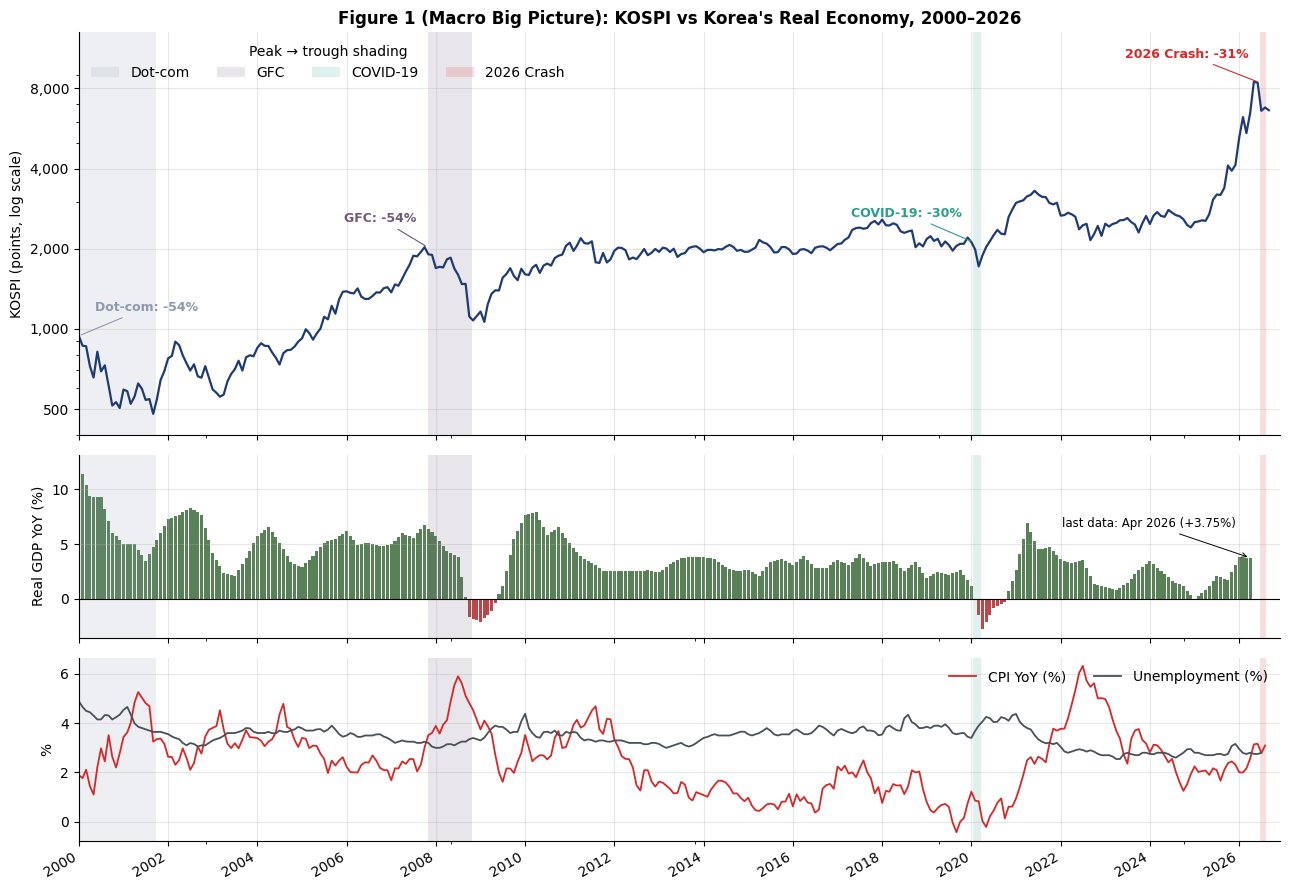

In [4]:
fig, axes = plt.subplots(3, 1, figsize=(13, 9), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 1]})

# Panel 1: KOSPI on log scale (pandas .plot with logy=True)
ax = axes[0]
dm["KOSPI"].plot(ax=ax, logy=True, color=C["kospi"], lw=1.6, label="_nolegend_")
ax.set_yticks([500, 1000, 2000, 4000, 8000])
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"{v:,.0f}"))
ax.yaxis.set_minor_formatter(plt.NullFormatter()); ax.set_ylim(400, 13000)
ax.set_ylabel("KOSPI (points, log scale)")
shade_crises(ax)
crises.apply(lambda r: ax.annotate(
    f"{r.name}: {r['Drawdown_%']:.0f}%",
    xy=(max(r["Peak"], pd.Timestamp(MACRO_START)), dm["KOSPI"].asof(max(r["Peak"], pd.Timestamp(MACRO_START)))),
    xytext=(12 if r.name == "Dot-com" else -8, 18), textcoords="offset points",
    ha="left" if r.name == "Dot-com" else "right", fontsize=9, fontweight="bold",
    color=CRISIS_COLORS[r.name], arrowprops=dict(arrowstyle="-", color=CRISIS_COLORS[r.name], lw=0.8)), axis=1)
ax.legend(loc="upper left", ncol=4, title="Peak → trough shading")
ax.set_title("Figure 1 (Macro Big Picture): KOSPI vs Korea's Real Economy, 2000–2026")

# Panel 2: Real GDP YoY as bars, coloured by sign with np.where (vectorised)
ax = axes[1]
g = dm["GDP_YoY"].dropna()
ax.bar(g.index, g, width=25, color=np.where(g >= 0, "#588157", "#bc4749"))
ax.axhline(0, color="black", lw=0.8); ax.set_ylabel("Real GDP YoY (%)")
ax.annotate(f"last data: {g.index[-1]:%b %Y} ({g.iloc[-1]:+.2f}%)", xy=(g.index[-1], g.iloc[-1]),
            xytext=(-10, 22), textcoords="offset points", ha="right", fontsize=8.5,
            arrowprops=dict(arrowstyle="->", lw=0.7))
shade_crises(ax, label=False)

# Panel 3: CPI YoY and unemployment (pandas .plot on two columns)
ax = axes[2]
dm[["CPI_YoY", "Unemployment_Korea"]].plot(ax=ax, color=[C["cpi"], C["rate"]], lw=1.3)
ax.legend(["CPI YoY (%)", "Unemployment (%)"], loc="upper right", ncol=2)
ax.set_ylabel("%"); ax.set_xlabel("")
shade_crises(ax, label=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(pd.Timestamp(MACRO_START), dm.index.max() + pd.DateOffset(months=3))
fig.tight_layout()
save(fig, "fig01_macro_big_picture")

In [5]:
display(crises[["Peak", "Trough", "Drawdown_%", "Weeks_to_trough"]].assign(
    Peak=lambda d: d["Peak"].dt.date, Trough=lambda d: d["Trough"].dt.date).round(1))

gdp_last_d, gdp_last = last_obs(df_m["GDP_YoY"]), df_m["GDP_YoY"].dropna().iloc[-1]
u_jun, u_jul = df_m.loc["2026-06-01", "Unemployment_Korea"], df_m.loc["2026-07-01", "Unemployment_Korea"]
c_jun, c_jul = df_m.loc["2026-06-01", "CPI_YoY"], df_m.loc["2026-07-01", "CPI_YoY"]

display(Markdown(f"""
**ข้อสรุปสำคัญ:** อัตราการว่างงานอยู่ที่ **{u_jun:.2f}%** (มิ.ย.) และ **{u_jul:.2f}%** (ก.ค.) เงินเฟ้ออยู่ที่ **{c_jun:.2f}%** และ **{c_jul:.2f}%** ตามลำดับ ใกล้เคียงระดับปกติ ส่วน GDP YoY ล่าสุด ({th(gdp_last_d)}) ยังเป็นบวกที่ **{gdp_last:+.2f}%** ต่างจาก 3 วิกฤตในอดีตที่ดัชนีร่วงพร้อมเศรษฐกิจจริงชะลอตัวหรือหดตัว **สรุป:** การร่วงปี 2026 ({crises.loc['2026 Crash','Drawdown_%']:.1f}% ใน {crises.loc['2026 Crash','Weeks_to_trough']:.0f} สัปดาห์) ไม่มีลักษณะของวิกฤตเศรษฐกิจมหภาคภายในประเทศ
"""))


,Peak,Trough,Drawdown_%,Weeks_to_trough
Crisis,,,,
Dot-com,1999-12-31,2001-09-21,-54.1,90
GFC,2007-10-26,2008-10-24,-53.7,52
COVID-19,2020-01-17,2020-03-20,-30.4,9
2026 Crash,2026-06-19,2026-08-07,-30.9,7



**ข้อสรุปสำคัญ:** อัตราการว่างงานอยู่ที่ **2.75%** (มิ.ย.) และ **2.80%** (ก.ค.) เงินเฟ้ออยู่ที่ **3.16%** และ **2.79%** ตามลำดับ ใกล้เคียงระดับปกติ ส่วน GDP YoY ล่าสุด (เม.ย. 2026) ยังเป็นบวกที่ **+3.75%** ต่างจาก 3 วิกฤตในอดีตที่ดัชนีร่วงพร้อมเศรษฐกิจจริงชะลอตัวหรือหดตัว **สรุป:** การร่วงปี 2026 (-30.9% ใน 7 สัปดาห์) ไม่มีลักษณะของวิกฤตเศรษฐกิจมหภาคภายในประเทศ


> **ข้อควรระวัง:** GDP รายเดือนได้จากการ interpolate ข้อมูลรายไตรมาสซึ่งดึงค่าไตรมาสถัดไปมาใช้ จึงห้ามใช้เป็นตัวแปรพยากรณ์ และต้องระบุเสมอว่าค่าล่าสุดคือเดือน เม.ย. 2026 ไม่ใช่ ณ วันเกิดเหตุ (จุดพีค 19 มิ.ย. 2026)
>
> **ที่มา:** KOSPI จาก yfinance · Real GDP จาก FRED · CPI จาก OECD SDMX · Unemployment จาก FRED · คำนวณโดยผู้จัดทำ

## 2. ก่อนวิกฤต: มีสัญญาณจากเศรษฐกิจมหภาคหรือไม่ (H1)

### กราฟที่ 2 · ดัชนีชี้นำเศรษฐกิจเทียบกับเงินเฟ้อ
**คำถามของกราฟ:** ก่อนเกิดวิกฤต มีสัญญาณเศรษฐกิจชะลอตัวพร้อมเงินเฟ้อสูง (Stagflation) ก่อตัวขึ้นหรือไม่

**สิ่งที่กราฟแสดง:** เส้น OECD CLI (แกนซ้าย) เทียบกับ CPI YoY (แกนขวา) แถบสีส้มระบายเดือนที่เข้าเงื่อนไข Stagflation คือ **CLI < 100 และ CPI > 3% พร้อมกัน** เส้นแนวตั้งระบุจุดพีคของแต่ละวิกฤต

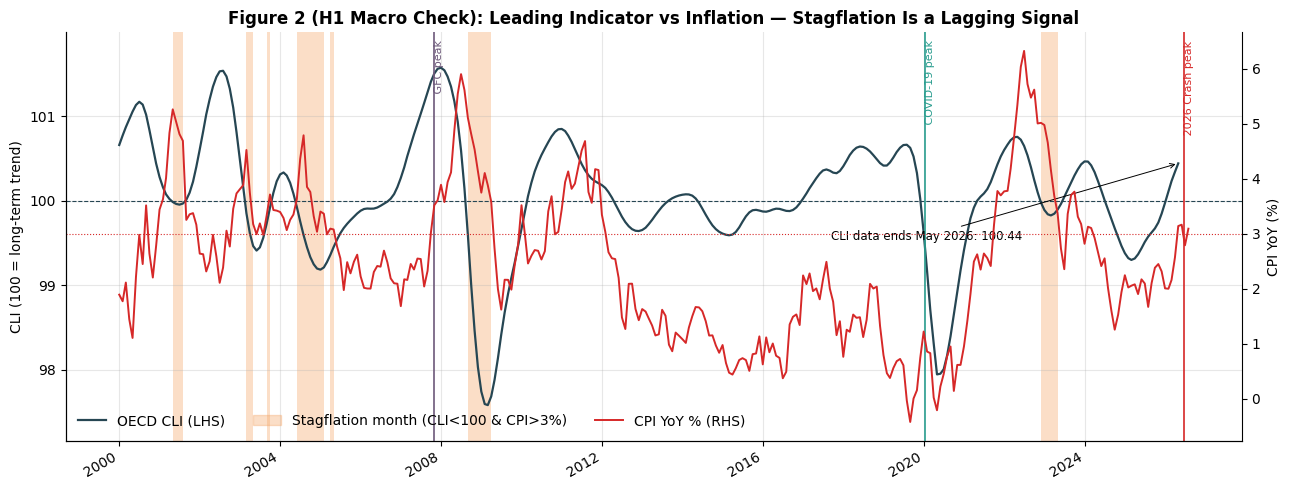

In [6]:
stag_all = (df_m["CLI"] < 100) & (df_m["CPI_YoY"] > 3)
stag = stag_all.loc[MACRO_START:]

fig, ax = plt.subplots(figsize=(13, 5))
dm["CLI"].plot(ax=ax, color=C["cli"], lw=1.6, label="OECD CLI (LHS)")
ax.axhline(100, color=C["cli"], ls="--", lw=0.8)
ax.set_ylabel("CLI (100 = long-term trend)")

ax2 = ax.twinx()
dm["CPI_YoY"].plot(ax=ax2, color=C["cpi"], lw=1.4, label="CPI YoY % (RHS)")
ax2.axhline(3, color=C["cpi"], ls=":", lw=0.8)
ax2.set_ylabel("CPI YoY (%)"); ax2.grid(False); ax2.spines["right"].set_visible(True)

# Stagflation months: one vectorised fill_between with a boolean mask (no loop)
ax.fill_between(stag.index, 0, 1, where=stag.values, transform=ax.get_xaxis_transform(),
                step="post", color="#f4a261", alpha=0.35, lw=0)

# Crisis peaks: ax.vlines accepts arrays, so all four lines are drawn in one call
pk = crises[crises["Peak"] >= pd.Timestamp(MACRO_START)]
ax.vlines(pk["Peak"], 0, 1, transform=ax.get_xaxis_transform(),
          colors=pk.index.map(CRISIS_COLORS), lw=1.2)
pk.apply(lambda r: ax.text(r["Peak"], 0.98, f" {r.name} peak", transform=ax.get_xaxis_transform(),
                           color=CRISIS_COLORS[r.name], fontsize=8, va="top", rotation=90), axis=1)

# Mark where the CLI series ends
cli_end = last_obs(df_m["CLI"])
ax.annotate(f"CLI data ends {cli_end:%b %Y}: {df_m.loc[cli_end,'CLI']:.2f}",
            xy=(cli_end, df_m.loc[cli_end, "CLI"]), xytext=(-250, -55), textcoords="offset points",
            fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=0.7))

h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
h1.append(plt.Rectangle((0, 0), 1, 1, color="#f4a261", alpha=0.35)); l1.append("Stagflation month (CLI<100 & CPI>3%)")
ax.legend(h1 + h2, l1 + l2, loc="lower left", ncol=3)
ax.set_xlabel("")
ax.set_title("Figure 2 (H1 Macro Check): Leading Indicator vs Inflation — Stagflation Is a Lagging Signal")
fig.tight_layout()
save(fig, "fig02_h1_cli_vs_cpi")

In [7]:
# Stagflation months per year, and in the 12 months before each crisis peak
stag_by_year = stag.resample("YS").sum().loc[lambda s: s > 0]
stag_by_year.index = stag_by_year.index.year
stag_pre_peak = crises["Peak"].apply(lambda p: int(stag_all.loc[p - pd.DateOffset(months=12):p].sum()))
stag_fall     = crises.apply(lambda r: int(stag_all.loc[r["Peak"]:r["Trough"] + pd.DateOffset(months=12)].sum()), axis=1)
display(pd.DataFrame({"12M before peak": stag_pre_peak, "peak → trough + 12M": stag_fall}))
print("Stagflation months by year:", stag_by_year.to_dict())

cli_tail = df_m["CLI"].dropna()
cli_sd   = df_m["CLI"].std()
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ไม่มีวิกฤตใดใน 4 ครั้งที่เกิดสัญญาณ Stagflation ในช่วง 12 เดือนก่อนจุดพีค (ทุกวิกฤต = {stag_pre_peak.max()} เดือน) สัญญาณที่เคยเกิดขึ้นในปี 2001 ({stag_by_year.get(2001, 0)} เดือน) และ 2008 ({stag_by_year.get(2008, 0)} เดือน) เกิด**ระหว่าง**ที่ตลาดกำลังร่วงไปแล้ว จึงเป็นตัวชี้วัดที่ตามหลังเหตุการณ์ ไม่ใช่สัญญาณเตือนล่วงหน้า ปี 2026: CLI เดือน {th(cli_tail.index[-1])} อยู่ที่ **{cli_tail.iloc[-1]:.2f}** เหนือระดับ 100 และเพิ่มขึ้นต่อเนื่องจาก {cli_tail.loc['2025-12-01']:.2f} ในเดือน ธ.ค. 2025 จึงไม่เข้าเงื่อนไข **สรุป:** ตัดภาวะ Stagflation ออกจากคำอธิบายสาเหตุของวิกฤตปี 2026 ได้ แต่**ไม่สามารถ**อ้างว่า "อดีตมีรูปแบบนี้แล้วปี 2026 แตกต่าง" เพราะอดีตก็ไม่มีสัญญาณล่วงหน้าเช่นกัน
"""))


,12M before peak,peak → trough + 12M
Crisis,,
Dot-com,0,4
GFC,0,8
COVID-19,0,0
2026 Crash,0,0


Stagflation months by year: {2001: 4, 2003: 6, 2004: 7, 2005: 4, 2008: 4, 2009: 4, 2010: 1, 2022: 1, 2023: 5}



**ข้อสรุปสำคัญ:** ไม่มีวิกฤตใดใน 4 ครั้งที่เกิดสัญญาณ Stagflation ในช่วง 12 เดือนก่อนจุดพีค (ทุกวิกฤต = 0 เดือน) สัญญาณที่เคยเกิดขึ้นในปี 2001 (4 เดือน) และ 2008 (4 เดือน) เกิด**ระหว่าง**ที่ตลาดกำลังร่วงไปแล้ว จึงเป็นตัวชี้วัดที่ตามหลังเหตุการณ์ ไม่ใช่สัญญาณเตือนล่วงหน้า ปี 2026: CLI เดือน พ.ค. 2026 อยู่ที่ **100.44** เหนือระดับ 100 และเพิ่มขึ้นต่อเนื่องจาก 99.85 ในเดือน ธ.ค. 2025 จึงไม่เข้าเงื่อนไข **สรุป:** ตัดภาวะ Stagflation ออกจากคำอธิบายสาเหตุของวิกฤตปี 2026 ได้ แต่**ไม่สามารถ**อ้างว่า "อดีตมีรูปแบบนี้แล้วปี 2026 แตกต่าง" เพราะอดีตก็ไม่มีสัญญาณล่วงหน้าเช่นกัน


> **ข้อควรระวัง:** CLI มีข้อมูลถึงเดือน พ.ค. 2026 เท่านั้น (ก่อนจุดพีค 1 เดือน) ต้องเขียนว่า "ข้อมูลล่าสุดก่อนเกิดเหตุ" ไม่ใช่ "ขณะเกิดเหตุ" และค่าเบี่ยงเบนมาตรฐานของ CLI ทั้งชุดมีเพียงราว 1.2 จุด ค่า 100.44 จึงหมายถึงอยู่ในเกณฑ์ปกติเล็กน้อย ไม่ใช่เศรษฐกิจแข็งแกร่งผิดปกติ · เกณฑ์ CPI > 3% เป็นเกณฑ์เฝ้าระวังที่ผู้จัดทำกำหนด (เป้าหมายเงินเฟ้อของ BOK คือ 2%)
>
> **ที่มา:** OECD Composite Leading Indicator และ CPI จาก OECD SDMX · คำนวณโดยผู้จัดทำ

### กราฟที่ 3 · แรงกดดันเงินเฟ้อจากฝั่งต้นทุนน้ำมัน
**คำถามของกราฟ:** เงินเฟ้อที่ขยับขึ้นก่อนวิกฤตมาจากราคาน้ำมันหรือไม่ และส่งผ่านด้วยความล่าช้ากี่เดือน

**สิ่งที่กราฟแสดง:** สามแผงเรียงจากบนลงล่าง
- **แผง ①** ราคาน้ำมันเบรนท์ในสกุลวอน เปลี่ยนแปลงแบบ YoY ช่วงปี 2024–2026
- **แผง ②** CPI YoY ช่วงเวลาเดียวกัน แกนเริ่มที่ 0 พร้อมเส้นเป้าหมายเงินเฟ้อของธนาคารกลางเกาหลี (2%) และเส้นเฝ้าระวัง (3%)
- **แผง ③** ค่าสหสัมพันธ์ระหว่าง CPI กับราคาน้ำมันที่ย้อนหลังไป k เดือน (ข้อมูลรายเดือน 2000–2026) เพื่อหาระยะเวลาส่งผ่าน

แถบสีส้มในแผง ① และ ② คือช่วงที่น้ำมันพุ่งและส่งผ่านไปยัง CPI (มี.ค.–มิ.ย. 2026) เส้นแดงแนวตั้งคือวันที่ KOSPI ทำจุดสูงสุด

*แยกน้ำมันและ CPI เป็นคนละแผงแทนการใช้กราฟสองแกน Y เพราะกราฟสองแกนที่ตั้งสเกลแยกกันทำให้ตำแหน่งที่เส้นซ้อนกันไม่มีความหมายทางสถิติ ความสัมพันธ์จริงวัดด้วยค่า r ในแผง ③*

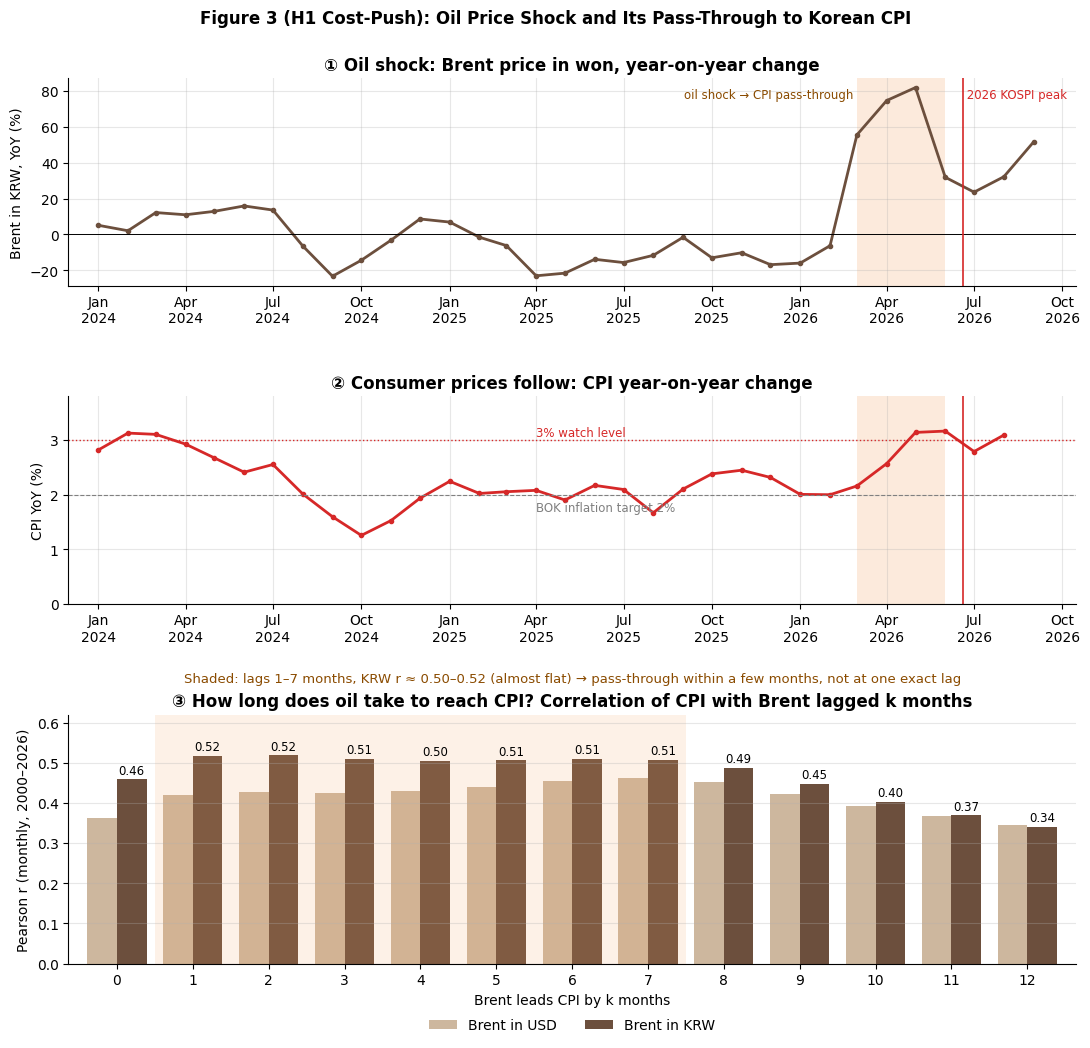

In [8]:
zoom = dm.loc["2024-01-01":]
lags = pd.Series(range(13), name="lag")
lag_corr = pd.DataFrame({
    "Brent in USD": lags.apply(lambda k: dm["CPI_YoY"].corr(dm["Brent_USD_YoY"].shift(k))),
    "Brent in KRW": lags.apply(lambda k: dm["CPI_YoY"].corr(dm["Brent_KRW_YoY"].shift(k))),
}).set_index(lags)
best_usd, best_krw = lag_corr["Brent in USD"].idxmax(), lag_corr["Brent in KRW"].idxmax()
krw_17 = lag_corr.loc[1:7, "Brent in KRW"]
SHOCK = (pd.Timestamp("2026-03-01"), pd.Timestamp("2026-06-01"))
BOK_TARGET, CPI_WATCH = 2, 3

fig, axes = plt.subplots(3, 1, figsize=(13, 11.5), gridspec_kw={"height_ratios": [1, 1, 1.2], "hspace": 0.5})
a1, a2, a3 = axes

# Panel 1: Brent in KRW, YoY
a1.plot(zoom.index, zoom["Brent_KRW_YoY"], color=C["oil"], lw=2, marker="o", ms=3)
a1.axhline(0, color="black", lw=0.7); a1.set_ylabel("Brent in KRW, YoY (%)")
a1.set_title("① Oil shock: Brent price in won, year-on-year change")

# Panel 2: CPI YoY, axis from 0, with the BOK target and the watch level
a2.plot(zoom.index, zoom["CPI_YoY"], color=C["cpi"], lw=2, marker="o", ms=3)
a2.axhline(CPI_WATCH, color=C["cpi"], ls=":", lw=1)
a2.text(pd.Timestamp("2025-04-01"), CPI_WATCH + 0.08, f"{CPI_WATCH}% watch level", fontsize=8.5, color=C["cpi"])
a2.axhline(BOK_TARGET, color="grey", ls="--", lw=0.8)
a2.text(pd.Timestamp("2025-04-01"), BOK_TARGET - 0.12, f"BOK inflation target {BOK_TARGET}%", fontsize=8.5, color="grey", va="top")
a2.set_ylim(0, 3.8); a2.set_ylabel("CPI YoY (%)")
a2.set_title("② Consumer prices follow: CPI year-on-year change")

def style_time_panel(a):
    # Same time window, quarterly ticks, shock window and KOSPI peak on both time panels
    a.set_xlim(pd.Timestamp("2023-12-01"), pd.Timestamp("2026-10-15"))
    a.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 4, 7, 10]))
    a.xaxis.set_major_formatter(mdates.DateFormatter("%b\n%Y"))
    a.axvspan(*SHOCK, color="#f4a261", alpha=0.22, lw=0)
    a.axvline(P26, color=CRISIS_COLORS["2026 Crash"], lw=1.2)

pd.Series([a1, a2]).apply(style_time_panel)
a1.text(P26, 0.95, " 2026 KOSPI peak", transform=a1.get_xaxis_transform(),
        color=CRISIS_COLORS["2026 Crash"], fontsize=8.5, va="top")
a1.text(SHOCK[0], 0.95, "oil shock → CPI pass-through ", transform=a1.get_xaxis_transform(),
        fontsize=8.5, va="top", ha="right", color="#8a4b00")

# Panel 3: lag correlation, full width (pandas .plot kind='bar')
lag_corr.plot(kind="bar", ax=a3, color=["#cdb79e", C["oil"]], width=0.78, rot=0)
a3.axvspan(0.5, 7.5, color="#f4a261", alpha=0.15, lw=0)
a3.bar_label(a3.containers[1], fmt="%.2f", padding=2, fontsize=8.5)
a3.set_ylim(0, 0.62); a3.grid(axis="x", visible=False)
a3.set_xlabel("Brent leads CPI by k months"); a3.set_ylabel("Pearson r (monthly, 2000–2026)")
a3.legend(loc="upper center", bbox_to_anchor=(0.5, -0.17), ncol=2)
a3.set_title("③ How long does oil take to reach CPI? Correlation of CPI with Brent lagged k months")
a3.text(0.5, 1.13, f"Shaded: lags 1–7 months, KRW r ≈ {krw_17.min():.2f}–{krw_17.max():.2f} (almost flat) "
        "→ pass-through within a few months, not at one exact lag",
        transform=a3.transAxes, ha="center", fontsize=9.5, color="#8a4b00")

fig.suptitle("Figure 3 (H1 Cost-Push): Oil Price Shock and Its Pass-Through to Korean CPI", fontweight="bold", y=0.94)
save(fig, "fig03_h1_oil_cost_push")

In [9]:
oil_tbl = dm.loc["2026-02-01":"2026-06-01", ["Brent_Oil", "Brent_KRW_YoY", "CPI_YoY", "PolicyRate_Korea"]]
display(oil_tbl.round(2))

brent_feb, brent_mar = dm.loc["2026-02-01", "Brent_Oil"], dm.loc["2026-03-01", "Brent_Oil"]
rate_2026 = dm.loc["2026-01-01":"2026-07-01", "PolicyRate_Korea"]
rate_flat = rate_2026.nunique() == 1
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ราคาเบรนท์กระโดดจาก **{brent_feb:.2f}** ดอลลาร์ (ก.พ. 2026) เป็น **{brent_mar:.2f}** ดอลลาร์ (มี.ค.) เพิ่มขึ้น **{(brent_mar/brent_feb-1)*100:.0f}%** ภายในเดือนเดียว เมื่อวัดในสกุลวอนแบบ YoY ขึ้นไปสูงสุด {dm.loc['2026-05-01','Brent_KRW_YoY']:+.1f}% ในเดือน พ.ค. เงินเฟ้อตอบสนองตามมาโดยทะลุเส้นเฝ้าระวัง 3% ในเดือน พ.ค. ({dm.loc['2026-05-01','CPI_YoY']:.2f}%) และ มิ.ย. ({dm.loc['2026-06-01','CPI_YoY']:.2f}%) ตรงกับช่วงที่ดัชนีทำจุดสูงสุด ({fmt_d(P26)}) ค่าสหสัมพันธ์สูงสุดอยู่ที่ระยะล่าช้า **{best_krw} เดือน** เมื่อวัดในสกุลวอน (r = {lag_corr.loc[best_krw,'Brent in KRW']:.2f}) แต่ค่า r ระหว่าง lag 1–7 เดือนใกล้เคียงกันมาก ({krw_17.min():.2f}–{krw_17.max():.2f}) จึงสรุปได้เพียงว่า**ส่งผ่านภายในไม่กี่เดือน** ไม่ใช่ระบุเดือนที่แน่นอน (ราคาในสกุลวอนให้ค่า r สูงกว่าสกุลดอลลาร์ทุก lag — สูงสุดในสกุลดอลลาร์ = {lag_corr.loc[best_usd,'Brent in USD']:.2f} ที่ lag {best_usd} เดือน) อัตราดอกเบี้ย{'ไม่เปลี่ยนแปลงเลย' if rate_flat else 'มีการเปลี่ยนแปลง'}ตลอดช่วง ม.ค.–ก.ค. 2026 → **เงินเฟ้อจากฝั่งต้นทุนที่นโยบายการเงินไม่ได้ตอบสนอง**
"""))


,Brent_Oil,Brent_KRW_YoY,CPI_YoY,PolicyRate_Korea
Date,,,,
2026-02-01,71.12,-6.27,2.00,1.0
2026-03-01,109.72,55.42,2.16,1.0
2026-04-01,114.29,74.55,2.57,1.0
2026-05-01,107.10,81.79,3.14,1.0
2026-06-01,84.14,31.83,3.16,1.0



**ข้อสรุปสำคัญ:** ราคาเบรนท์กระโดดจาก **71.12** ดอลลาร์ (ก.พ. 2026) เป็น **109.72** ดอลลาร์ (มี.ค.) เพิ่มขึ้น **54%** ภายในเดือนเดียว เมื่อวัดในสกุลวอนแบบ YoY ขึ้นไปสูงสุด +81.8% ในเดือน พ.ค. เงินเฟ้อตอบสนองตามมาโดยทะลุเส้นเฝ้าระวัง 3% ในเดือน พ.ค. (3.14%) และ มิ.ย. (3.16%) ตรงกับช่วงที่ดัชนีทำจุดสูงสุด (19 มิ.ย. 2026) ค่าสหสัมพันธ์สูงสุดอยู่ที่ระยะล่าช้า **2 เดือน** เมื่อวัดในสกุลวอน (r = 0.52) แต่ค่า r ระหว่าง lag 1–7 เดือนใกล้เคียงกันมาก (0.50–0.52) จึงสรุปได้เพียงว่า**ส่งผ่านภายในไม่กี่เดือน** ไม่ใช่ระบุเดือนที่แน่นอน (ราคาในสกุลวอนให้ค่า r สูงกว่าสกุลดอลลาร์ทุก lag — สูงสุดในสกุลดอลลาร์ = 0.46 ที่ lag 7 เดือน) อัตราดอกเบี้ยไม่เปลี่ยนแปลงเลยตลอดช่วง ม.ค.–ก.ค. 2026 → **เงินเฟ้อจากฝั่งต้นทุนที่นโยบายการเงินไม่ได้ตอบสนอง**


> **ข้อควรระวัง:** r ≈ 0.52 ถือว่าปานกลาง อธิบายความแปรปรวนของเงินเฟ้อได้ราวหนึ่งในสี่ (r² ≈ 0.27) จึงเป็นปัจจัยร่วม ไม่ใช่สาเหตุเดียว · เส้น 2% คือเป้าหมายเงินเฟ้อทางการของธนาคารกลางเกาหลี ส่วนเส้น 3% เป็นเกณฑ์เฝ้าระวังที่งานนี้กำหนดเอง (ใช้เกณฑ์เดียวกับกราฟ 2) · ห้ามสรุปเรื่องระดับอัตราดอกเบี้ยที่แท้จริง เพราะซีรีส์ที่มีคือ Discount Rate
>
> **ที่มา:** Brent และ USDKRW จาก FRED · CPI จาก OECD SDMX · Discount Rate จาก FRED `INTDSRKRM193N` · คำนวณโดยผู้จัดทำ

## 3. ความกลัวระดับโลกและค่าเงิน (H2)

### กราฟที่ 4 · ความกลัวของตลาดโลกและความต้องการสินทรัพย์ปลอดภัย
**คำถามของกราฟ:** การร่วงของ KOSPI ปี 2026 เกิดจากความตื่นตระหนกของตลาดการเงินโลกหรือไม่

**สิ่งที่กราฟแสดง:** แผงบนคือ VIX (ค่าเฉลี่ยรายเดือน) พร้อมเส้นค่าเฉลี่ยระยะยาวและเขตตื่นตระหนกที่ 30 และจุดสีดำคือ VIX สูงสุด (รายสัปดาห์) ระหว่างการร่วงของแต่ละวิกฤต แผงล่างคือราคาทองคำ YoY

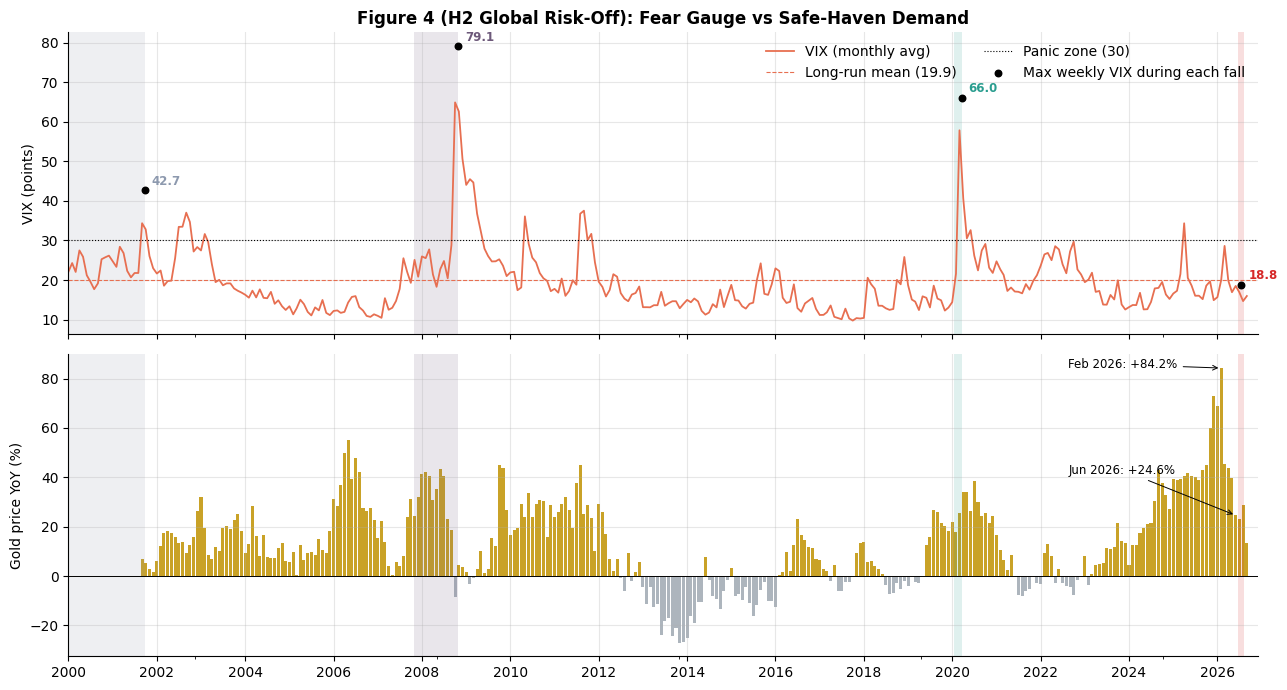

In [10]:
vix_mean = df_w["VIX_Index"].mean()
crises["Max_VIX"] = crises.apply(lambda r: df_w.loc[r["Peak"]:r["Trough"], "VIX_Index"].max(), axis=1)
crises["Max_VIX_date"] = crises.apply(lambda r: df_w.loc[r["Peak"]:r["Trough"], "VIX_Index"].idxmax(), axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)
ax = axes[0]
dm["VIX_Index"].plot(ax=ax, color=C["vix"], lw=1.3, label="VIX (monthly avg)")
ax.axhline(vix_mean, color=C["vix"], ls="--", lw=0.8, label=f"Long-run mean ({vix_mean:.1f})")
ax.axhline(30, color="black", ls=":", lw=0.8, label="Panic zone (30)")
ax.scatter(crises["Max_VIX_date"], crises["Max_VIX"], color="black", s=22, zorder=5,
           label="Max weekly VIX during each fall")
crises.apply(lambda r: ax.annotate(f"{r['Max_VIX']:.1f}", (r["Max_VIX_date"], r["Max_VIX"]),
                                   xytext=(5, 4), textcoords="offset points", fontsize=8.5,
                                   color=CRISIS_COLORS[r.name], fontweight="bold"), axis=1)
ax.set_ylabel("VIX (points)"); shade_crises(ax, label=False); ax.legend(loc="upper right", ncol=2)
ax.set_title("Figure 4 (H2 Global Risk-Off): Fear Gauge vs Safe-Haven Demand")

ax = axes[1]
gy = dm["Gold_YoY"].dropna()
ax.bar(gy.index, gy, width=25, color=np.where(gy >= 0, C["gold"], C["grey"]))
ax.axhline(0, color="black", lw=0.7); ax.set_ylabel("Gold price YoY (%)")
g_pk = gy.loc["2025-06-01":].idxmax()
ax.annotate(f"{g_pk:%b %Y}: {gy[g_pk]:+.1f}%", xy=(g_pk, gy[g_pk]), xytext=(-110, 0), textcoords="offset points",
            fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=0.7))
ax.annotate(f"Jun 2026: {gy['2026-06-01']:+.1f}%", xy=(pd.Timestamp("2026-06-01"), gy["2026-06-01"]),
            xytext=(-120, 30), textcoords="offset points", fontsize=8.5, arrowprops=dict(arrowstyle="->", lw=0.7))
shade_crises(ax, label=False)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_xlim(pd.Timestamp(MACRO_START), dm.index.max() + pd.DateOffset(months=3)); ax.set_xlabel("")
fig.tight_layout()
save(fig, "fig04_h2_vix_gold")

In [11]:
display(crises[["Max_VIX"]].round(1).assign(Above_panic_30=lambda d: d["Max_VIX"] > 30))
gold_26 = dm.loc["2026-01-01":, "Gold_YoY"].dropna().round(1)
gold_26.index = gold_26.index.strftime("%b %Y")
display(gold_26.to_frame("Gold YoY %").T)

vx = crises["Max_VIX"]
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ใน 3 วิกฤตก่อนหน้า VIX ทะลุเขตตื่นตระหนกที่ 30 ทุกครั้ง: Dot-com **{vx['Dot-com']:.1f}**, GFC **{vx['GFC']:.1f}**, COVID-19 **{vx['COVID-19']:.1f}** ปี 2026 ค่าสูงสุดอยู่ที่เพียง **{vx['2026 Crash']:.1f}** ต่ำกว่าค่าเฉลี่ยระยะยาว ({vix_mean:.1f}) ด้วยซ้ำ ตลาดโลกไม่ได้ตื่นตระหนกตลอดช่วงที่ KOSPI ร่วง ทองคำ YoY **ชะลอตัวลง** จาก {dm.loc[g_pk,'Gold_YoY']:+.1f}% ({th(g_pk)}) เหลือ {dm.loc['2026-06-01','Gold_YoY']:+.1f}% (มิ.ย.) และ {dm.loc['2026-07-01','Gold_YoY']:+.1f}% (ก.ค.) ไม่มีแรงซื้อสินทรัพย์ปลอดภัยรอบใหม่ระหว่างวิกฤต **สรุป:** การร่วงครั้งนี้ไม่ได้มาจากภาวะหลบความเสี่ยงระดับโลก (Global Risk-Off)
"""))


,Max_VIX,Above_panic_30
Crisis,,
Dot-com,42.7,True
GFC,79.1,True
COVID-19,66.0,True
2026 Crash,18.8,False


Date,Jan 2026,Feb 2026,Mar 2026,Apr 2026,May 2026,Jun 2026,Jul 2026,Aug 2026,Sep 2026
Gold YoY %,68.7,84.2,45.6,43.7,39.7,24.6,23.1,28.8,13.5



**ข้อสรุปสำคัญ:** ใน 3 วิกฤตก่อนหน้า VIX ทะลุเขตตื่นตระหนกที่ 30 ทุกครั้ง: Dot-com **42.7**, GFC **79.1**, COVID-19 **66.0** ปี 2026 ค่าสูงสุดอยู่ที่เพียง **18.8** ต่ำกว่าค่าเฉลี่ยระยะยาว (19.9) ด้วยซ้ำ ตลาดโลกไม่ได้ตื่นตระหนกตลอดช่วงที่ KOSPI ร่วง ทองคำ YoY **ชะลอตัวลง** จาก +84.2% (ก.พ. 2026) เหลือ +24.6% (มิ.ย.) และ +23.1% (ก.ค.) ไม่มีแรงซื้อสินทรัพย์ปลอดภัยรอบใหม่ระหว่างวิกฤต **สรุป:** การร่วงครั้งนี้ไม่ได้มาจากภาวะหลบความเสี่ยงระดับโลก (Global Risk-Off)


> **ข้อควรระวัง:** ทองคำยังเติบโตเกิน 20% YoY ตลอดช่วงวิกฤต (ต่ำกว่า 20% ครั้งแรกในเดือน ก.ย. ซึ่งหลังจุดต่ำสุดแล้ว) จึงต้องเขียนว่า "ชะลอตัว" ไม่ใช่ "ลดลงต่ำกว่า 20%" และ VIX สูงสุดเป็นฐานรายสัปดาห์ อาจต่ำกว่าจุดสูงสุดระหว่างวัน
>
> **ที่มา:** VIX และ Gold Futures (GC=F) จาก yfinance · คำนวณโดยผู้จัดทำ

### กราฟที่ 5 · ค่าเงินวอนเป็นสัญญาณเตือนได้หรือไม่
**คำถามของกราฟ:** ค่าเงินวอนที่อ่อนผิดปกติ ใช้เป็นสัญญาณเตือนว่าตลาดหุ้นกำลังจะร่วงได้หรือไม่

**สิ่งที่กราฟแสดง:** แผงเดียว — USDKRW พร้อมกรอบค่าเฉลี่ยเคลื่อนที่ 36 เดือน ± 2 SD จุดสีแดงคือเดือนที่ค่าเงินอ่อนทะลุกรอบบน (Z > 2) และกล่องสรุปผลการทดสอบผลตอบแทน KOSPI ในเดือนถัดไป

*ฉบับนี้ลดจากเดิม (เส้น + scatter + boxplot 4 กลุ่ม) เหลือแผงเดียว และนำเสนอเป็นผลลัพธ์เชิงปฏิเสธ (Null Result)*

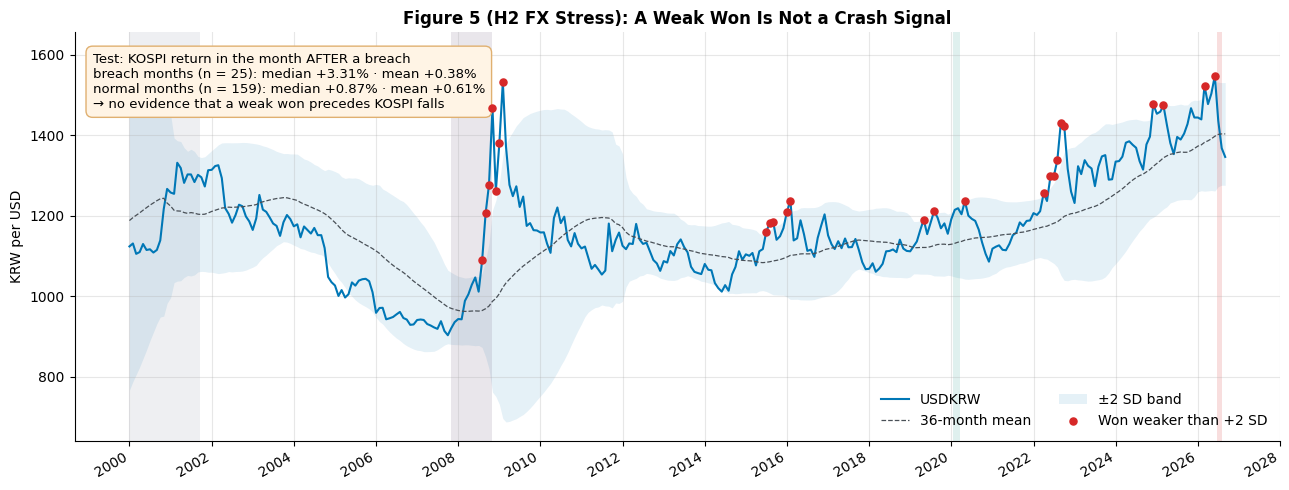

In [12]:
fx = dm[["USDKRW", "USDKRW_MA36", "USDKRW_SD36", "USDKRW_Z36", "KOSPI_fwd_1M"]].copy()
fx["Zone"] = pd.cut(fx["USDKRW_Z36"], [-np.inf, -1, 1, 2, np.inf],
                    labels=["Z < -1 (won strong)", "-1 to 1 (normal)", "1 to 2 (tight)", "Z > 2 (breach)"])
fx_test = fx.dropna(subset=["USDKRW_Z36", "KOSPI_fwd_1M"]).groupby("Zone", observed=False)["KOSPI_fwd_1M"] \
            .agg(n="count", median="median", mean="mean")
breach = fx[fx["USDKRW_Z36"] > 2]

fig, ax = plt.subplots(figsize=(13, 5))
fx["USDKRW"].plot(ax=ax, color=C["fx"], lw=1.5, label="USDKRW")
fx["USDKRW_MA36"].plot(ax=ax, color=C["rate"], lw=0.9, ls="--", label="36-month mean")
ax.fill_between(fx.index, fx["USDKRW_MA36"] - 2 * fx["USDKRW_SD36"], fx["USDKRW_MA36"] + 2 * fx["USDKRW_SD36"],
                color=C["fx"], alpha=0.10, lw=0, label="±2 SD band")
ax.scatter(breach.index, breach["USDKRW"], color="#d62828", s=26, zorder=5, label="Won weaker than +2 SD")
shade_crises(ax, label=False)
z = fx_test.loc["Z > 2 (breach)"]; nz = fx_test.loc["-1 to 1 (normal)"]
ax.text(0.015, 0.95,
        f"Test: KOSPI return in the month AFTER a breach\n"
        f"breach months (n = {z['n']:.0f}): median {z['median']:+.2f}% · mean {z['mean']:+.2f}%\n"
        f"normal months (n = {nz['n']:.0f}): median {nz['median']:+.2f}% · mean {nz['mean']:+.2f}%\n"
        f"→ no evidence that a weak won precedes KOSPI falls",
        transform=ax.transAxes, va="top", fontsize=9.5,
        bbox=dict(boxstyle="round,pad=0.5", fc="#fff4e5", ec="#e0b070"))
ax.set_ylabel("KRW per USD"); ax.set_xlabel(""); ax.legend(loc="lower right", ncol=2)
ax.xaxis.set_major_locator(mdates.YearLocator(2)); ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.set_title("Figure 5 (H2 FX Stress): A Weak Won Is Not a Crash Signal")
fig.tight_layout()
save(fig, "fig05_h2_fx_null_result")

In [13]:
display(fx_test.round(2))
fx_jun = dm.loc["2026-06-01", ["USDKRW", "USDKRW_Z36"]]
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ตั้งแต่ปี 2000 มีเดือนที่ค่าเงินวอนอ่อนทะลุกรอบ +2 SD ทั้งหมด **{z['n']:.0f} เดือน** ผลตอบแทน KOSPI ในเดือนถัดจากการทะลุกรอบมีมัธยฐาน **{z['median']:+.2f}%** และค่าเฉลี่ย **{z['mean']:+.2f}%** เทียบกับเดือนปกติ (มัธยฐาน {nz['median']:+.2f}%, ค่าเฉลี่ย {nz['mean']:+.2f}%) → **ไม่พบหลักฐาน**ว่าค่าเงินอ่อนนำไปสู่การร่วง (ค่าเฉลี่ยต่ำกว่ามัธยฐานมาก แปลว่ามีบางเดือนที่ร่วงแรง เช่นช่วง GFC ปี 2008 ที่ค่าเงินทะลุกรอบ**ระหว่าง**ที่ตลาดกำลังร่วง แต่ส่วนใหญ่ตลาดไม่ได้ร่วงตาม ค่าเงินจึงเป็นตัวแปรที่เกิดร่วม ไม่ใช่ตัวนำ) เดือน มิ.ย. 2026 ค่าเงินอยู่ที่ **{fx_jun['USDKRW']:,.0f}** วอน/ดอลลาร์ (Z = {fx_jun['USDKRW_Z36']:.2f}) ซึ่งทะลุกรอบพอดีกับเดือนที่เกิดจุดพีค แต่ตามหลักฐานเชิงสถิติข้างต้น ไม่สามารถใช้เป็นตัวจุดชนวนได้ **สรุป:** เป็นผลเชิงปฏิเสธที่มีคุณค่า ช่วยตัดตัวแปรค่าเงินออกจากคำอธิบายอย่างมีหลักฐาน
"""))


,n,median,mean
Zone,,,
Z < -1 (won strong),73,0.33,0.79
-1 to 1 (normal),159,0.87,0.61
1 to 2 (tight),63,0.61,1.71
Z > 2 (breach),25,3.31,0.38



**ข้อสรุปสำคัญ:** ตั้งแต่ปี 2000 มีเดือนที่ค่าเงินวอนอ่อนทะลุกรอบ +2 SD ทั้งหมด **25 เดือน** ผลตอบแทน KOSPI ในเดือนถัดจากการทะลุกรอบมีมัธยฐาน **+3.31%** และค่าเฉลี่ย **+0.38%** เทียบกับเดือนปกติ (มัธยฐาน +0.87%, ค่าเฉลี่ย +0.61%) → **ไม่พบหลักฐาน**ว่าค่าเงินอ่อนนำไปสู่การร่วง (ค่าเฉลี่ยต่ำกว่ามัธยฐานมาก แปลว่ามีบางเดือนที่ร่วงแรง เช่นช่วง GFC ปี 2008 ที่ค่าเงินทะลุกรอบ**ระหว่าง**ที่ตลาดกำลังร่วง แต่ส่วนใหญ่ตลาดไม่ได้ร่วงตาม ค่าเงินจึงเป็นตัวแปรที่เกิดร่วม ไม่ใช่ตัวนำ) เดือน มิ.ย. 2026 ค่าเงินอยู่ที่ **1,549** วอน/ดอลลาร์ (Z = 2.21) ซึ่งทะลุกรอบพอดีกับเดือนที่เกิดจุดพีค แต่ตามหลักฐานเชิงสถิติข้างต้น ไม่สามารถใช้เป็นตัวจุดชนวนได้ **สรุป:** เป็นผลเชิงปฏิเสธที่มีคุณค่า ช่วยตัดตัวแปรค่าเงินออกจากคำอธิบายอย่างมีหลักฐาน


> **ข้อควรระวัง:** ใช้ผลตอบแทน**เดือนถัดไป**เพื่อหลีกเลี่ยง look-ahead bias และกลุ่มทะลุกรอบมีเพียง 25 เดือนซึ่งกระจุกอยู่ไม่กี่ช่วงเวลา ไม่ได้ทดสอบนัยสำคัญทางสถิติ ต้องระบุขนาดตัวอย่างกำกับเสมอ · ข้อมูลเป็นรายเดือน สัญญาณรายวันอาจให้ผลต่างออกไป (ดู Future Work)
>
> **ที่มา:** USDKRW จาก FRED · KOSPI จาก yfinance · คำนวณโดยผู้จัดทำ

## 4. เปรียบเทียบวิกฤต

### กราฟที่ 6 · เปรียบเทียบความเร็วและความลึกของการร่วง
**คำถามของกราฟ:** รูปแบบการร่วงของปี 2026 แตกต่างจากวิกฤตในอดีตอย่างไร

**สิ่งที่กราฟแสดง:** แผงซ้ายซ้อนเส้นทางราคาของทั้ง 4 วิกฤต (ตั้งจุดพีค = 100, แกนนอน = สัปดาห์นับจากพีค) แผงขวาคือแท่งความลึก พร้อมระยะเวลาร่วงและฟื้นตัว

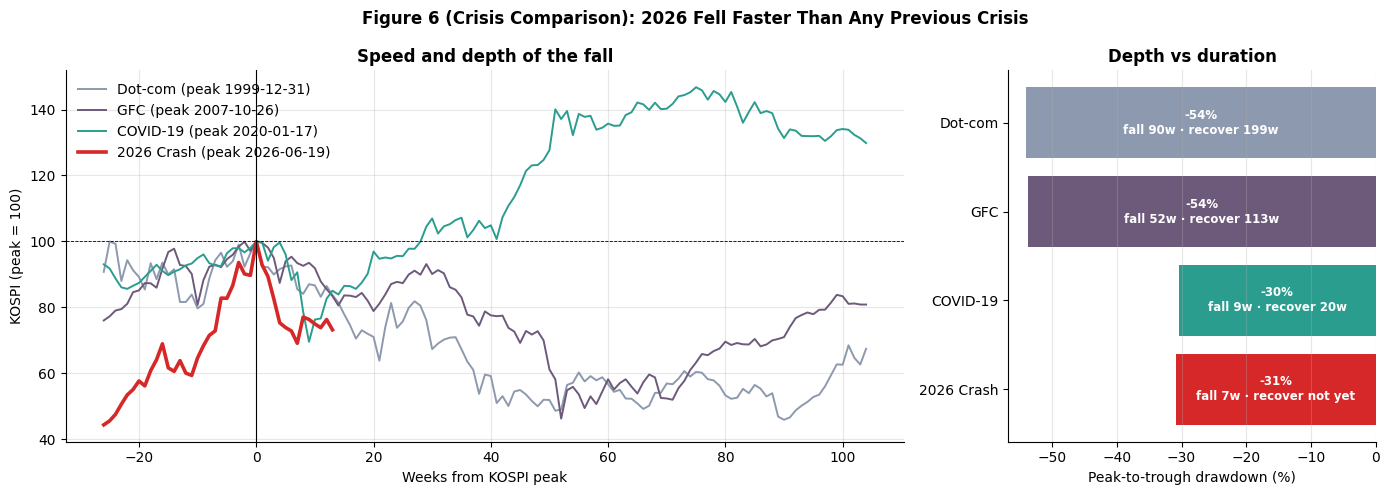

In [14]:
def path_from_peak(r):
    # KOSPI path from 26 weeks before to 104 weeks after the peak, indexed by weeks-from-peak
    s = df_w["KOSPI"].loc[r["Peak"] - pd.Timedelta(weeks=26): r["Peak"] + pd.Timedelta(weeks=104)]
    return pd.Series((s / r["Peak_KOSPI"] * 100).values, index=((s.index - r["Peak"]).days // 7))

paths = crises.apply(path_from_peak, axis=1).T.sort_index()        # rows = weeks from peak, columns = crises

fig, ax = plt.subplot_mosaic([["A", "A", "B"]], figsize=(14, 5))
a = ax["A"]
paths.plot(ax=a, color=paths.columns.map(CRISIS_COLORS).tolist(), lw=1.4)
a.lines[list(paths.columns).index("2026 Crash")].set_linewidth(2.6)
a.axvline(0, color="black", lw=0.8); a.axhline(100, color="black", lw=0.6, ls="--")
a.legend((paths.columns + " (peak " + crises.loc[paths.columns, "Peak"].dt.strftime("%Y-%m-%d") + ")").tolist(),
         loc="upper left")
a.set_xlabel("Weeks from KOSPI peak"); a.set_ylabel("KOSPI (peak = 100)")
a.set_title("Speed and depth of the fall")

b = ax["B"]
bars = b.barh(crises.index, crises["Drawdown_%"], color=crises.index.map(CRISIS_COLORS))
rec_txt = crises["Weeks_to_recover"].map(lambda w: "not yet" if pd.isna(w) else f"{w:.0f}w")
b.bar_label(bars, labels=(crises["Drawdown_%"].map("{:.0f}%".format) + "\nfall "
                          + crises["Weeks_to_trough"].map("{:.0f}w".format) + " · recover " + rec_txt).tolist(),
            label_type="center", color="white", fontsize=8.5, fontweight="bold")
b.set_xlabel("Peak-to-trough drawdown (%)"); b.invert_yaxis(); b.grid(axis="y", visible=False)
b.set_title("Depth vs duration")

fig.suptitle("Figure 6 (Crisis Comparison): 2026 Fell Faster Than Any Previous Crisis", fontweight="bold")
fig.tight_layout()
save(fig, "fig06_crisis_comparison")

In [15]:
display(crises[["Drawdown_%", "Weeks_to_trough", "Weeks_to_recover", "Pct_per_week"]].round(2))
k_last, dd_last = df_w["KOSPI"].iloc[-1], df_w["KOSPI_DD"].iloc[-1]
cr = crises
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ความลึกปี 2026 ที่ **{cr.loc['2026 Crash','Drawdown_%']:.1f}%** ใกล้เคียง COVID-19 ({cr.loc['COVID-19','Drawdown_%']:.1f}%) แต่ใช้เวลาน้อยกว่า คือ **{cr.loc['2026 Crash','Weeks_to_trough']:.0f} สัปดาห์** เทียบกับ {cr.loc['COVID-19','Weeks_to_trough']:.0f} สัปดาห์ เทียบกับวิกฤตเชิงโครงสร้าง Dot-com ({cr.loc['Dot-com','Weeks_to_trough']:.0f} สัปดาห์) และ GFC ({cr.loc['GFC','Weeks_to_trough']:.0f} สัปดาห์) ปี 2026 เร็วกว่าราว {cr.loc['GFC','Weeks_to_trough']/cr.loc['2026 Crash','Weeks_to_trough']:.0f}–{cr.loc['Dot-com','Weeks_to_trough']/cr.loc['2026 Crash','Weeks_to_trough']:.0f} เท่า อัตราการร่วงเฉลี่ย **{-cr.loc['2026 Crash','Pct_per_week']:.1f}% ต่อสัปดาห์** สูงที่สุดใน 4 วิกฤต (COVID-19 {-cr.loc['COVID-19','Pct_per_week']:.1f}%, GFC {-cr.loc['GFC','Pct_per_week']:.1f}%, Dot-com {-cr.loc['Dot-com','Pct_per_week']:.1f}%) ความเร็วระดับนี้สอดคล้องกับการปรับสถานะแบบเร่งด่วน มากกว่าการปรับมุมมองต่อปัจจัยพื้นฐานซึ่งมักใช้เวลานานกว่า
"""))


,Drawdown_%,Weeks_to_trough,Weeks_to_recover,Pct_per_week
Crisis,,,,
Dot-com,-54.06,90,199.0,-0.60
GFC,-53.71,52,113.0,-1.03
COVID-19,-30.41,9,20.0,-3.38
2026 Crash,-30.86,7,NaN,-4.41



**ข้อสรุปสำคัญ:** ความลึกปี 2026 ที่ **-30.9%** ใกล้เคียง COVID-19 (-30.4%) แต่ใช้เวลาน้อยกว่า คือ **7 สัปดาห์** เทียบกับ 9 สัปดาห์ เทียบกับวิกฤตเชิงโครงสร้าง Dot-com (90 สัปดาห์) และ GFC (52 สัปดาห์) ปี 2026 เร็วกว่าราว 7–13 เท่า อัตราการร่วงเฉลี่ย **4.4% ต่อสัปดาห์** สูงที่สุดใน 4 วิกฤต (COVID-19 3.4%, GFC 1.0%, Dot-com 0.6%) ความเร็วระดับนี้สอดคล้องกับการปรับสถานะแบบเร่งด่วน มากกว่าการปรับมุมมองต่อปัจจัยพื้นฐานซึ่งมักใช้เวลานานกว่า


> **ข้อควรระวัง:** สถานะ "not yet" คำนวณ ณ วันที่ 18 ก.ย. 2026 ซึ่ง KOSPI อยู่ที่ราว 6,627 จุด (ต่ำกว่าพีค ~26.8%) คือฟื้นจากจุดต่ำสุดแล้วบางส่วนแต่ยังไม่กลับระดับเดิม ตัวเลขนี้อาจเปลี่ยนเมื่อมีข้อมูลเพิ่ม
>
> **ที่มา:** KOSPI จาก yfinance · คำนวณโดยผู้จัดทำ

## 5. สะพานเชื่อม Macro → Micro

### กราฟที่ 7 · ปัจจัยใดเคลื่อนไหวไปพร้อมกับ KOSPI มากที่สุด
**คำถามของกราฟ:** ในรอบ 10 ปี อะไรคือปัจจัยที่สัมพันธ์กับการเคลื่อนไหวของ KOSPI มากที่สุด

**สิ่งที่กราฟแสดง:** แท่งแนวนอนเรียงลำดับค่าสหสัมพันธ์ (Pearson r) ระหว่างผลตอบแทนรายสัปดาห์ของ KOSPI กับตัวแปรอีก 9 ตัว ช่วงปี 2016–2026 สีน้ำเงิน = สัมพันธ์เชิงบวก สีแดง = เชิงลบ

*ฉบับนี้เปลี่ยนจาก Heatmap เป็น Bar Chart โดยตัวแปรครบ 9 ตัวเท่าเดิม*

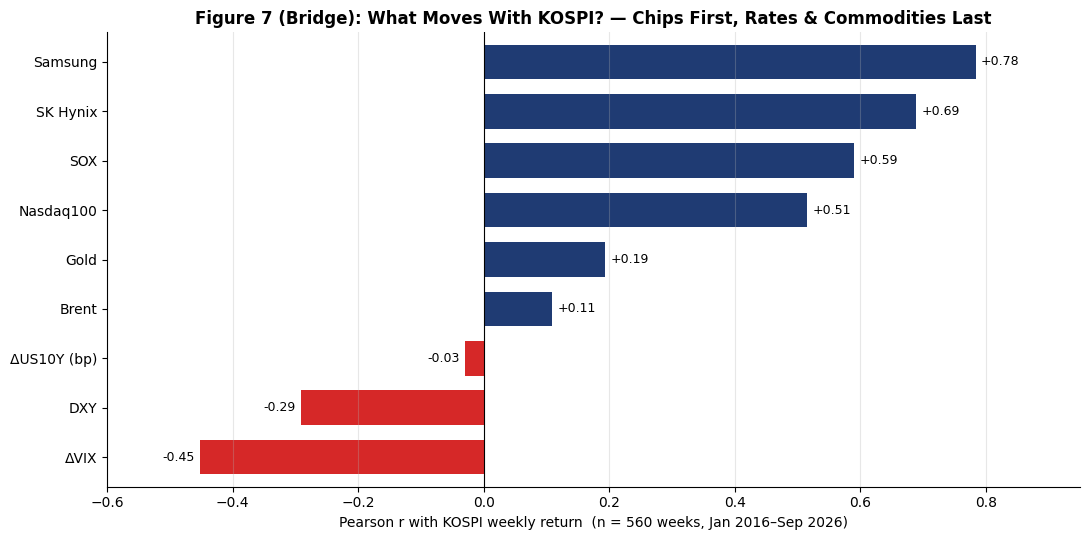

In [16]:
CORR_COLS = {"KOSPI_ret": "KOSPI", "Samsung_ret": "Samsung", "SK_Hynix_ret": "SK Hynix", "SOX_Index_ret": "SOX",
             "Nasdaq100_Index_ret": "Nasdaq100", "US10Y_chg_bp": "ΔUS10Y (bp)", "DXY_Index_ret": "DXY",
             "Brent_Oil_ret": "Brent", "VIX_chg": "ΔVIX", "Gold_Price_ret": "Gold"}
corr_data = dw[list(CORR_COLS)].rename(columns=CORR_COLS).dropna()
kospi_corr = corr_data.corr()["KOSPI"].drop("KOSPI").sort_values()

fig, ax = plt.subplots(figsize=(11, 5.5))
kospi_corr.plot(kind="barh", ax=ax, color=np.where(kospi_corr >= 0, C["kospi"], "#d62828"), width=0.7)
ax.bar_label(ax.containers[0], fmt="%+.2f", padding=4, fontsize=9)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlim(-0.6, 0.95); ax.grid(axis="y", visible=False)
ax.set_xlabel(f"Pearson r with KOSPI weekly return  (n = {len(corr_data)} weeks, {corr_data.index.min():%b %Y}–{corr_data.index.max():%b %Y})")
ax.set_title("Figure 7 (Bridge): What Moves With KOSPI? — Chips First, Rates & Commodities Last")
fig.tight_layout()
save(fig, "fig07_bridge_correlation")

In [17]:
display(kospi_corr.sort_values(ascending=False).round(3).to_frame("r with KOSPI").T)
kc = kospi_corr
display(Markdown(f"""
**ข้อสรุปสำคัญ:** สองอันดับแรกคือหุ้นชิปในประเทศ: **Samsung (r = {kc['Samsung']:.2f})** และ **SK Hynix (r = {kc['SK Hynix']:.2f})** ตามด้วยดัชนีชิปสหรัฐฯ **SOX ({kc['SOX']:.2f})** และ **Nasdaq100 ({kc['Nasdaq100']:.2f})** สินค้าโภคภัณฑ์และอัตราดอกเบี้ยสัมพันธ์น้อยที่สุด: Gold ({kc['Gold']:+.2f}), Brent ({kc['Brent']:+.2f}) และบอนด์ยีลด์สหรัฐฯ ที่เกือบเป็นศูนย์ ({kc['ΔUS10Y (bp)']:+.2f}) ตัวแปรความเสี่ยงระดับโลกมีความสัมพันธ์เชิงลบปานกลาง: ΔVIX ({kc['ΔVIX']:+.2f}) และ DXY ({kc['DXY']:+.2f}) แปลว่า**ในภาวะปกติ** KOSPI มักร่วงเมื่อตลาดโลกกลัว ดังนั้นการที่ VIX ไม่ขยับเลยในปี 2026 (กราฟ 4) ยิ่งตอกย้ำว่าครั้งนี้ไม่ใช่รูปแบบปกติ (เลือกกรอบ 10 ปีแทน 26 ปี เพราะกลุ่มหุ้นที่มีอิทธิพลสูงสุดในปี 2000 ไม่ใช่กลุ่มเดียวกับปัจจุบัน) **สรุป:** การเคลื่อนไหวของ KOSPI ถูกกำหนดโดยกลุ่มเซมิคอนดักเตอร์เป็นหลัก มากกว่าปัจจัยมหภาค อัตราดอกเบี้ย และสินค้าโภคภัณฑ์
"""))


,Samsung,SK Hynix,SOX,Nasdaq100,Gold,Brent,ΔUS10Y (bp),DXY,ΔVIX
r with KOSPI,0.784,0.689,0.591,0.515,0.193,0.109,-0.03,-0.291,-0.452



**ข้อสรุปสำคัญ:** สองอันดับแรกคือหุ้นชิปในประเทศ: **Samsung (r = 0.78)** และ **SK Hynix (r = 0.69)** ตามด้วยดัชนีชิปสหรัฐฯ **SOX (0.59)** และ **Nasdaq100 (0.51)** สินค้าโภคภัณฑ์และอัตราดอกเบี้ยสัมพันธ์น้อยที่สุด: Gold (+0.19), Brent (+0.11) และบอนด์ยีลด์สหรัฐฯ ที่เกือบเป็นศูนย์ (-0.03) ตัวแปรความเสี่ยงระดับโลกมีความสัมพันธ์เชิงลบปานกลาง: ΔVIX (-0.45) และ DXY (-0.29) แปลว่า**ในภาวะปกติ** KOSPI มักร่วงเมื่อตลาดโลกกลัว ดังนั้นการที่ VIX ไม่ขยับเลยในปี 2026 (กราฟ 4) ยิ่งตอกย้ำว่าครั้งนี้ไม่ใช่รูปแบบปกติ (เลือกกรอบ 10 ปีแทน 26 ปี เพราะกลุ่มหุ้นที่มีอิทธิพลสูงสุดในปี 2000 ไม่ใช่กลุ่มเดียวกับปัจจุบัน) **สรุป:** การเคลื่อนไหวของ KOSPI ถูกกำหนดโดยกลุ่มเซมิคอนดักเตอร์เป็นหลัก มากกว่าปัจจัยมหภาค อัตราดอกเบี้ย และสินค้าโภคภัณฑ์


> **ข้อควรระวัง:** Samsung และ SK Hynix **เป็นองค์ประกอบของ KOSPI เอง** ค่า r ที่สูงจึงสะท้อนน้ำหนักในดัชนีบางส่วน ไม่ใช่ความสัมพันธ์ระหว่างสินทรัพย์อิสระ อย่างไรก็ตามข้อเท็จจริงนี้กลับเป็นหลักฐานโดยตรงของการกระจุกตัวที่วัดในกราฟ 9 · ความสัมพันธ์ไม่ได้พิสูจน์ความเป็นเหตุเป็นผล
>
> **ที่มา:** yfinance (หุ้น, ดัชนี, VIX, ทองคำ) · FRED (Brent, US10Y) · คำนวณโดยผู้จัดทำ

## 6. Micro: โครงสร้างตลาด (H3)

### กราฟที่ 8 · ใครคือผู้ลากดัชนีตลอด 10 ปี
**คำถามของกราฟ:** การเติบโตของ KOSPI ในรอบ 10 ปีมาจากหุ้นกลุ่มใด และเคลื่อนไหวตามวัฏจักรใด

**สิ่งที่กราฟแสดง:** กราฟเส้นมาตราส่วนลอการิทึม ตั้งฐานสัปดาห์แรกของปี 2016 = 100 เปรียบเทียบ KOSPI กับ Samsung, SK Hynix และ SOX

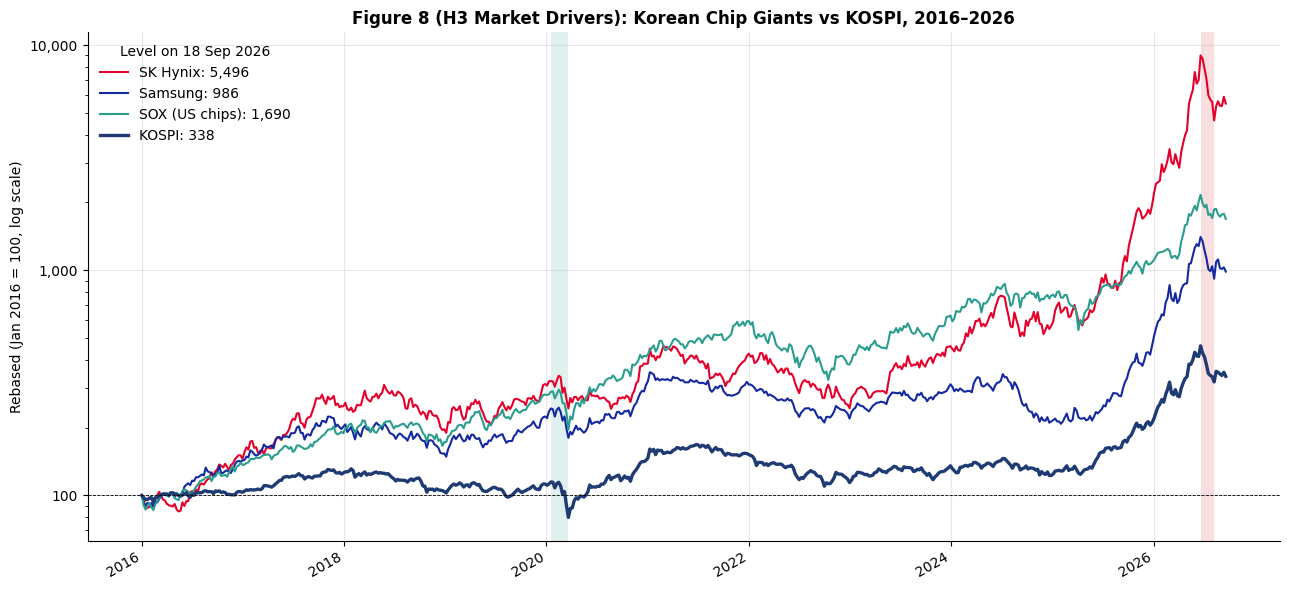

In [18]:
REB = pd.Series({"SK_Hynix": "SK Hynix", "Samsung": "Samsung", "SOX_Index": "SOX (US chips)", "KOSPI": "KOSPI"})
REB_COLORS = [C["hynix"], C["samsung"], C["sox"], C["kospi"]]
reb = dw[REB.index].dropna()
reb = reb / reb.iloc[0] * 100
reb_latest = reb.iloc[-1]

fig, ax = plt.subplots(figsize=(13, 6))
# Legend labels built with vectorised string operations (no loop)
reb.set_axis((REB + ": " + reb_latest.map("{:,.0f}".format)).values, axis=1) \
   .plot(ax=ax, logy=True, color=REB_COLORS, lw=1.5)
ax.lines[-1].set_linewidth(2.4)
ax.axhline(100, color="black", lw=0.6, ls="--")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, p: f"{v:,.0f}"))
shade_crises(ax, start=MICRO_START, label=False)
ax.legend(title=f"Level on {reb.index[-1]:%d %b %Y}", loc="upper left")
ax.set_ylabel(f"Rebased ({reb.index[0]:%b %Y} = 100, log scale)"); ax.set_xlabel("")
ax.set_title("Figure 8 (H3 Market Drivers): Korean Chip Giants vs KOSPI, 2016–2026")
fig.tight_layout()
save(fig, "fig08_h3_rebased_drivers")

In [19]:
growth = (reb_latest / 100).rename(REB).round(1)
display(growth.to_frame("x times since 2016").T)
display(Markdown(f"""
**ข้อสรุปสำคัญ:** ตลอด 10 ปี KOSPI เติบโต **{growth['KOSPI']:.1f} เท่า** ขณะที่ Samsung เติบโต **{growth['Samsung']:.1f} เท่า** และ SK Hynix เติบโตถึง **{growth['SK Hynix']:.1f} เท่า** หุ้นชิปทั้งสองตัวเคลื่อนไหวเกาะวัฏจักรของดัชนีชิปโลก SOX ซึ่งเติบโต **{growth['SOX (US chips)']:.1f} เท่า** ในช่วงเดียวกัน ช่องว่างระหว่างการเติบโตของหุ้นชิปกับดัชนีรวม หมายความว่าน้ำหนักของหุ้นกลุ่มนี้ในดัชนีเพิ่มขึ้นต่อเนื่อง ซึ่งเป็นที่มาของการกระจุกตัวในกราฟถัดไป
"""))


,SK Hynix,Samsung,SOX (US chips),KOSPI
x times since 2016,55.0,9.9,16.9,3.4



**ข้อสรุปสำคัญ:** ตลอด 10 ปี KOSPI เติบโต **3.4 เท่า** ขณะที่ Samsung เติบโต **9.9 เท่า** และ SK Hynix เติบโตถึง **55.0 เท่า** หุ้นชิปทั้งสองตัวเคลื่อนไหวเกาะวัฏจักรของดัชนีชิปโลก SOX ซึ่งเติบโต **16.9 เท่า** ในช่วงเดียวกัน ช่องว่างระหว่างการเติบโตของหุ้นชิปกับดัชนีรวม หมายความว่าน้ำหนักของหุ้นกลุ่มนี้ในดัชนีเพิ่มขึ้นต่อเนื่อง ซึ่งเป็นที่มาของการกระจุกตัวในกราฟถัดไป


> **ข้อควรระวัง:** ราคาที่ใช้ปรับการแตกพาร์แล้วแต่ไม่ได้ปรับเงินปันผล ตัวเลขการเติบโตจึงเป็นผลตอบแทนจากราคาเท่านั้น (price return) ไม่ใช่ผลตอบแทนรวม (total return)
>
> **ที่มา:** yfinance · คำนวณโดยผู้จัดทำ

### กราฟที่ 9 · การกระจุกตัวของตลาดเทียบกับการร่วงของดัชนี
**คำถามของกราฟ:** สัดส่วนของหุ้นขนาดใหญ่สุด 5 ตัวเพิ่มขึ้นจนทำให้ตลาดเปราะบางหรือไม่

**สิ่งที่กราฟแสดง:** แผงบนคือสัดส่วนมูลค่าตลาดของหุ้นใหญ่สุด (CR5 แบบปรับตัวหารให้เคลื่อนตามดัชนี) พร้อมเส้นแนวตั้งระบุจุดที่**จำนวนบริษัทในสูตรเปลี่ยน** และแถบสีเขียวคือกรอบปกติในยุค 5 บริษัท (2022–2025) แผงล่างคือระดับการร่วงของ KOSPI จากจุดสูงสุดตลอดกาล

*ฉบับนี้ตัดเส้น CR5 Raw (ตัวหารคงที่) ออก และเพิ่มการแบ่งยุคตามจำนวนบริษัท เพื่อไม่ให้เทียบ CR4 กับ CR5 ข้ามช่วง*

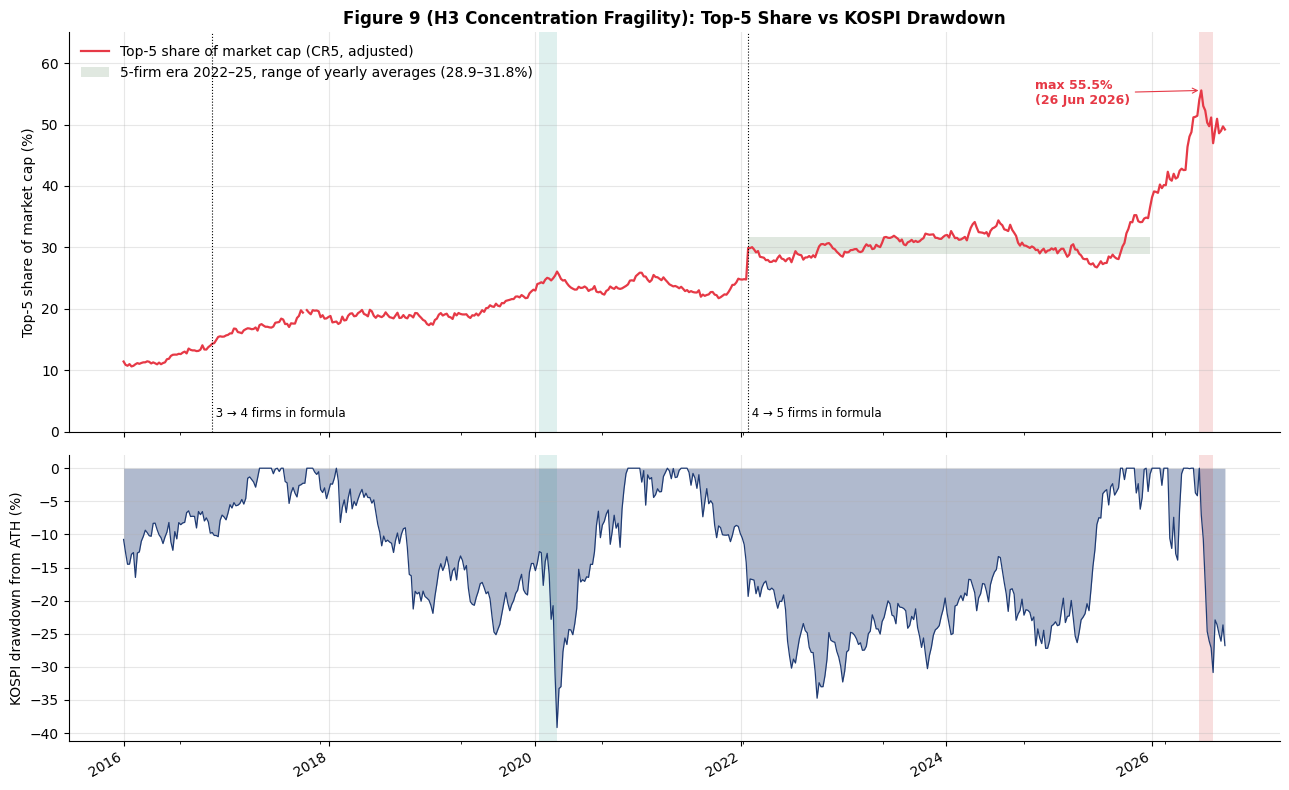

In [20]:
cr5 = dw["CR5_Adj"]
firms = dw["CR5_Company_Count"].where(~glitch.loc[MICRO_START:]).ffill()
firm_steps = firms.cummax().loc[lambda s: s.diff() > 0]            # dates when the firm count increases
cr5_year = pd.DataFrame({"CR5_Adj_%": cr5.resample("YS").mean(),
                         "n_firms": firms.resample("YS").max()})
cr5_year.index = cr5_year.index.year
cr5_five = cr5.where(firms == 5).loc[:"2025-12-31"].dropna()        # weeks counted with exactly 5 firms
five_era = cr5_five.resample("YS").mean()
five_era.index = five_era.index.year
cr5_max_d = cr5.idxmax()
cr5_at_peak = crises[["Peak"]].apply(lambda r: df_w.loc[r["Peak"], "CR5_Adj"], axis=1)

fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=True, gridspec_kw={"height_ratios": [1.4, 1]})
ax = axes[0]
cr5.plot(ax=ax, color=C["top5"], lw=1.6, label="Top-5 share of market cap (CR5, adjusted)")
ax.fill_between(cr5_five.index, five_era.min(), five_era.max(),
                color="#588157", alpha=0.18, lw=0, label=f"5-firm era 2022–25, range of yearly averages ({five_era.min():.1f}–{five_era.max():.1f}%)")
ax.vlines(firm_steps.index, 0, 1, transform=ax.get_xaxis_transform(), colors="black", lw=0.8, ls=":")
firm_steps.reset_index().apply(lambda r: ax.text(r["Date"], 0.03, f" {r.iloc[1]-1:.0f} → {r.iloc[1]:.0f} firms in formula",
                               transform=ax.get_xaxis_transform(), fontsize=8.5, va="bottom"), axis=1)
ax.annotate(f"max {cr5.max():.1f}%\n({cr5_max_d:%d %b %Y})", xy=(cr5_max_d, cr5.max()),
            xytext=(-120, -10), textcoords="offset points", fontsize=9, fontweight="bold", color=C["top5"],
            arrowprops=dict(arrowstyle="->", color=C["top5"], lw=0.8))
shade_crises(ax, start=MICRO_START, label=False)
ax.set_ylabel("Top-5 share of market cap (%)"); ax.set_ylim(0, 65); ax.legend(loc="upper left")
ax.set_title("Figure 9 (H3 Concentration Fragility): Top-5 Share vs KOSPI Drawdown")

ax = axes[1]
ax.fill_between(dw.index, dw["KOSPI_DD"], 0, color=C["kospi"], alpha=0.35, lw=0)
dw["KOSPI_DD"].plot(ax=ax, color=C["kospi"], lw=0.9)
shade_crises(ax, start=MICRO_START, label=False)
ax.set_ylabel("KOSPI drawdown from ATH (%)"); ax.set_xlabel("")
fig.tight_layout()
save(fig, "fig09_h3_concentration_drawdown")

In [21]:
display(cr5_year.round(1).T)
print("Firm-count change points:", firm_steps.astype(int).rename(lambda d: str(d.date())).to_dict())
cy = cr5_year["CR5_Adj_%"]
display(Markdown(f"""
**ข้อสรุปสำคัญ:** จำนวนบริษัทในสูตรไม่คงที่ เพิ่มจาก 3 → 4 บริษัทเมื่อ {th(firm_steps.index[0])} และ 4 → 5 บริษัทเมื่อ {th(firm_steps.index[-1])} การเทียบข้ามยุคจึงเป็นการเทียบ CR4 กับ CR5 ซึ่งไม่ถูกต้องตามหลักวิชาการ (เช่น ปี 2016 ที่ {cy[2016]:.1f}% ใช้เทียบกับปี 2026 ตรงๆ ไม่ได้) การเปรียบเทียบที่ถูกต้องทำภายในยุค 5 บริษัท: ปี 2022–2025 ค่าเฉลี่ยรายปีของ CR5 ทรงตัวในกรอบแคบ **{five_era.min():.1f}–{five_era.max():.1f}%** ติดต่อกัน 4 ปี (ค่ารายสัปดาห์แกว่งในช่วง {cr5_five.min():.1f}–{cr5_five.max():.1f}%) ปี 2026 ค่าเฉลี่ยกระโดดเป็น **{cy[2026]:.1f}%** และทำจุดสูงสุด **{cr5.max():.1f}%** ({thd(cr5_max_d)}) อยู่ที่ **{cr5_at_peak['2026 Crash']:.1f}%** ณ วันพีค โดยจำนวนบริษัทไม่เปลี่ยน → **เป็นการกระจุกตัวจริง ไม่ใช่ผลจากวิธีคำนวณ** เทียบ COVID-19 ที่ CR5 ณ จุดพีคอยู่ที่ {cr5_at_peak['COVID-19']:.1f}% โครงสร้างตลาดปี 2026 กระจุกตัวกว่าเดิม **{cr5_at_peak['2026 Crash']/cr5_at_peak['COVID-19']:.1f} เท่า**
"""))


Date,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025,2026
CR5_Adj_%,12.5,17.7,18.7,20.1,23.8,23.6,28.7,30.8,31.8,30.1,45.8
n_firms,4.0,4.0,4.0,4.0,4.0,4.0,5.0,5.0,5.0,5.0,5.0


Firm-count change points: {'2016-11-11': 4, '2022-01-28': 5}



**ข้อสรุปสำคัญ:** จำนวนบริษัทในสูตรไม่คงที่ เพิ่มจาก 3 → 4 บริษัทเมื่อ พ.ย. 2016 และ 4 → 5 บริษัทเมื่อ ม.ค. 2022 การเทียบข้ามยุคจึงเป็นการเทียบ CR4 กับ CR5 ซึ่งไม่ถูกต้องตามหลักวิชาการ (เช่น ปี 2016 ที่ 12.5% ใช้เทียบกับปี 2026 ตรงๆ ไม่ได้) การเปรียบเทียบที่ถูกต้องทำภายในยุค 5 บริษัท: ปี 2022–2025 ค่าเฉลี่ยรายปีของ CR5 ทรงตัวในกรอบแคบ **28.9–31.8%** ติดต่อกัน 4 ปี (ค่ารายสัปดาห์แกว่งในช่วง 26.7–36.5%) ปี 2026 ค่าเฉลี่ยกระโดดเป็น **45.8%** และทำจุดสูงสุด **55.5%** (26 มิ.ย. 2026) อยู่ที่ **54.0%** ณ วันพีค โดยจำนวนบริษัทไม่เปลี่ยน → **เป็นการกระจุกตัวจริง ไม่ใช่ผลจากวิธีคำนวณ** เทียบ COVID-19 ที่ CR5 ณ จุดพีคอยู่ที่ 24.1% โครงสร้างตลาดปี 2026 กระจุกตัวกว่าเดิม **2.2 เท่า**


> **ข้อควรระวัง:** CR5 ดิบใช้ตัวหารเป็นมูลค่าตลาดรวม ณ วันดึงข้อมูลค่าเดียว จึงต้องปรับตัวหารให้เคลื่อนตามดัชนีก่อนใช้ ค่าที่ได้ยังเป็นค่าประมาณ เพราะสมมติว่ามูลค่าตลาดรวมเคลื่อนไหวตามดัชนี และใช้จำนวนหุ้นจดทะเบียน ณ วันดึงข้อมูลย้อนหลังทั้งช่วง
>
> **ที่มา:** KRX market-cap snapshot + ราคาจาก yfinance · คำนวณโดยผู้จัดทำ

### กราฟที่ 10 · ความเสียหายกระจุกอยู่ที่ใคร และความผันผวนฉีกตัวหรือไม่
**คำถามของกราฟ:** มูลค่าตลาดที่หายไประหว่างวิกฤตมาจากหุ้นกลุ่มใด และความผันผวนของหุ้นชิปต่างจากตลาดรวมแค่ไหน

**สิ่งที่กราฟแสดง:** แผงบน**แยก 2 แผง** (COVID-19 | 2026) แต่ละแผงเทียบ 2 แท่ง คือ *น้ำหนักของ Top-5 ณ จุดพีค* กับ *สัดส่วนความเสียหายที่มาจาก Top-5* ถ้าแท่งขวาสูงกว่าแท่งซ้าย แปลว่าความเสียหายกระจุกเกินสัดส่วน แผงล่างเต็มความกว้างคือความผันผวน 4 สัปดาห์ของหุ้นชิปเทียบกับ KOSPI โดยค่าที่ใช้เปรียบเทียบคือค่าสูงสุด**ระหว่างจุดพีคถึงจุดต่ำสุด**ของแต่ละวิกฤต

*แยกแผงซ้ายเดิม (stacked bar ที่อ่านสับสน) เป็น 2 แผง และขยายกราฟความผันผวนเต็มความกว้าง*

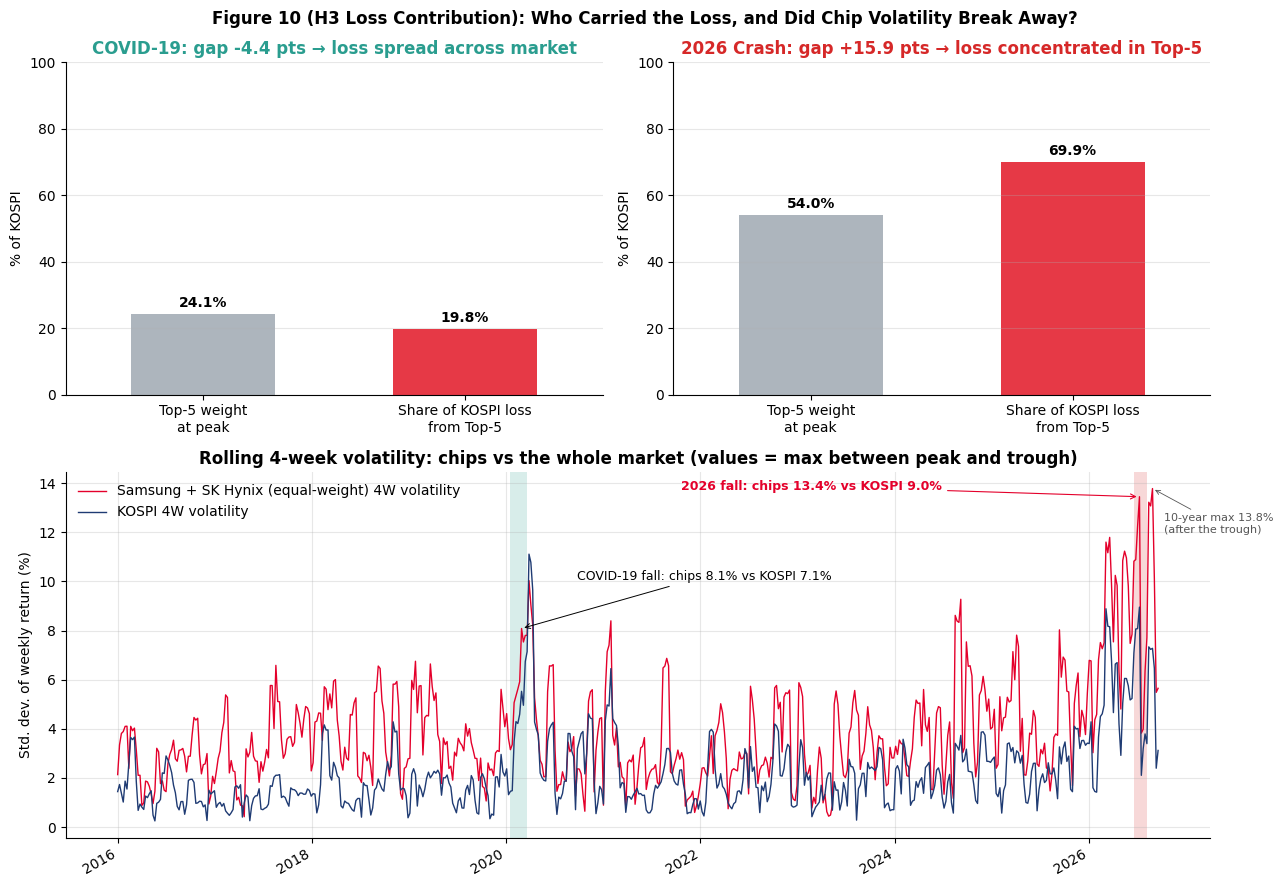

In [22]:
PAIR = ["COVID-19", "2026 Crash"]

def loss_split(r):
    # Loss share: fall in Top-5 cap / fall in total cap. The snapshot denominator cancels out.
    p, t = r["Peak"], r["Trough"]
    total_drop = (df_w.loc[p, "KOSPI"] - df_w.loc[t, "KOSPI"]) / kospi_ref
    top5_drop  = df_w.loc[p, "CR5_Concentration"] - df_w.loc[t, "CR5_Concentration"]
    return pd.Series({"Top-5 weight\nat peak": df_w.loc[p, "CR5_Adj"],
                      "Share of KOSPI loss\nfrom Top-5": top5_drop / total_drop * 100})

loss = crises.loc[PAIR].apply(loss_split, axis=1)
loss["Gap (pts)"] = loss.iloc[:, 1] - loss.iloc[:, 0]

# Max 4-week volatility during each fall (peak -> trough), for chips and for KOSPI
vol_max = crises.loc[PAIR].apply(
    lambda r: df_w.loc[r["Peak"]:r["Trough"], ["Tech_Vol_4W", "KOSPI_Vol_4W"]].max(), axis=1)
vol_date = crises.loc[PAIR].apply(lambda r: df_w.loc[r["Peak"]:r["Trough"], "Tech_Vol_4W"].idxmax(), axis=1)
tech_10y_max_d = dw["Tech_Vol_4W"].idxmax()

fig, ax = plt.subplot_mosaic([["A", "B"], ["C", "C"]], figsize=(13, 9), gridspec_kw={"height_ratios": [1, 1.1]})

def loss_panel(name, a):
    s = loss.loc[name].iloc[:2]
    s.plot(kind="bar", ax=a, color=[C["grey"], C["top5"]], width=0.55, rot=0)
    a.bar_label(a.containers[0], fmt="%.1f%%", padding=3, fontsize=10, fontweight="bold")
    a.set_ylim(0, 100); a.set_ylabel("% of KOSPI"); a.grid(axis="x", visible=False)
    gap = loss.loc[name, "Gap (pts)"]
    verdict = "loss spread across market" if gap < 0 else "loss concentrated in Top-5"
    a.set_title(f"{name}: gap {gap:+.1f} pts → {verdict}", color=CRISIS_COLORS[name])

loss_panel("COVID-19", ax["A"])
loss_panel("2026 Crash", ax["B"])

c = ax["C"]
dw[["Tech_Vol_4W", "KOSPI_Vol_4W"]].plot(ax=c, color=[C["hynix"], C["kospi"]], lw=1.0)
c.legend(["Samsung + SK Hynix (equal-weight) 4W volatility", "KOSPI 4W volatility"], loc="upper left")
shade_crises(c, start=MICRO_START, alpha=0.18, label=False)
vm = vol_max
c.annotate(f"2026 fall: chips {vm.loc['2026 Crash','Tech_Vol_4W']:.1f}% vs KOSPI {vm.loc['2026 Crash','KOSPI_Vol_4W']:.1f}%",
           xy=(vol_date["2026 Crash"], vm.loc["2026 Crash", "Tech_Vol_4W"]), xytext=(-330, 5), textcoords="offset points",
           fontsize=9, fontweight="bold", color=C["hynix"], arrowprops=dict(arrowstyle="->", color=C["hynix"], lw=0.8))
c.annotate(f"10-year max {dw['Tech_Vol_4W'].max():.1f}%\n(after the trough)",
           xy=(tech_10y_max_d, dw["Tech_Vol_4W"].max()), xytext=(8, -32), textcoords="offset points",
           fontsize=8, color="#555555", arrowprops=dict(arrowstyle="->", color="#555555", lw=0.6))
c.annotate(f"COVID-19 fall: chips {vm.loc['COVID-19','Tech_Vol_4W']:.1f}% vs KOSPI {vm.loc['COVID-19','KOSPI_Vol_4W']:.1f}%",
           xy=(vol_date["COVID-19"], vm.loc["COVID-19", "Tech_Vol_4W"]), xytext=(40, 35), textcoords="offset points",
           fontsize=9, arrowprops=dict(arrowstyle="->", lw=0.7))
c.set_ylabel("Std. dev. of weekly return (%)"); c.set_xlabel("")
c.set_title("Rolling 4-week volatility: chips vs the whole market (values = max between peak and trough)")

fig.suptitle("Figure 10 (H3 Loss Contribution): Who Carried the Loss, and Did Chip Volatility Break Away?",
             fontweight="bold")
fig.tight_layout()
save(fig, "fig10_h3_loss_contribution_vol")

In [23]:
display(loss.round(1).rename(columns=lambda s: s.replace("\n", " ")))
display(vol_max.round(1))
L = loss
display(Markdown(f"""
**ข้อสรุปสำคัญ:** COVID-19: Top-5 มีน้ำหนัก {L.iloc[0,0]:.1f}% และสร้างความเสียหาย {L.iloc[0,1]:.1f}% ซึ่ง**น้อยกว่า**น้ำหนักตัวเอง ({L.iloc[0,2]:+.1f} จุด) ความเสียหายกระจายทั่วตลาดตามปกติ ส่วน 2026 Crash: Top-5 มีน้ำหนัก **{L.iloc[1,0]:.1f}%** แต่สร้างความเสียหายถึง **{L.iloc[1,1]:.1f}%** สูงกว่าน้ำหนัก **{L.iloc[1,2]:+.1f} จุด** แรงขายกระจุกที่กลุ่มผู้นำตลาดอย่างผิดสัดส่วน ความผันผวนระหว่างช่วงร่วง: COVID-19 หุ้นชิป {vm.loc['COVID-19','Tech_Vol_4W']:.1f}% ใกล้เคียงตลาดรวม {vm.loc['COVID-19','KOSPI_Vol_4W']:.1f}% แต่ปี 2026 หุ้นชิปพุ่งถึง **{vm.loc['2026 Crash','Tech_Vol_4W']:.1f}%** ขณะที่ตลาดรวมอยู่ที่ {vm.loc['2026 Crash','KOSPI_Vol_4W']:.1f}% → **ความผันผวนฉีกตัวจากตลาดรวมอย่างชัดเจน** และหลังจุดต่ำสุดยังขึ้นต่อไปจนทำจุดสูงสุดในรอบ 10 ปีที่ {dw['Tech_Vol_4W'].max():.1f}% ({thd(tech_10y_max_d)})
"""))


,Top-5 weight at peak,Share of KOSPI loss from Top-5,Gap (pts)
Crisis,,,
COVID-19,24.1,19.8,-4.4
2026 Crash,54.0,69.9,15.9


,Tech_Vol_4W,KOSPI_Vol_4W
Crisis,,
COVID-19,8.1,7.1
2026 Crash,13.4,9.0



**ข้อสรุปสำคัญ:** COVID-19: Top-5 มีน้ำหนัก 24.1% และสร้างความเสียหาย 19.8% ซึ่ง**น้อยกว่า**น้ำหนักตัวเอง (-4.4 จุด) ความเสียหายกระจายทั่วตลาดตามปกติ ส่วน 2026 Crash: Top-5 มีน้ำหนัก **54.0%** แต่สร้างความเสียหายถึง **69.9%** สูงกว่าน้ำหนัก **+15.9 จุด** แรงขายกระจุกที่กลุ่มผู้นำตลาดอย่างผิดสัดส่วน ความผันผวนระหว่างช่วงร่วง: COVID-19 หุ้นชิป 8.1% ใกล้เคียงตลาดรวม 7.1% แต่ปี 2026 หุ้นชิปพุ่งถึง **13.4%** ขณะที่ตลาดรวมอยู่ที่ 9.0% → **ความผันผวนฉีกตัวจากตลาดรวมอย่างชัดเจน** และหลังจุดต่ำสุดยังขึ้นต่อไปจนทำจุดสูงสุดในรอบ 10 ปีที่ 13.8% (28 ส.ค. 2026)


> **ข้อควรระวัง:** ค่าความผันผวนที่ใช้เปรียบเทียบคือค่าสูงสุดระหว่างจุดพีคถึงจุดต่ำสุดของแต่ละวิกฤต ส่วนความผันผวนหลังจุดต่ำสุดเป็นช่วงฟื้นตัว (เช่น ช่วง COVID-19 ความผันผวนของ KOSPI ขึ้นไปราว 11% หลังจุดต่ำสุด) จึงไม่นำมาเปรียบเทียบ · สัดส่วนความเสียหายอาศัยสมมติฐานว่ามูลค่าตลาดรวมเคลื่อนไหวตามดัชนี ตัวหาร ณ วันดึงข้อมูลจะตัดกันหายไปในสูตร จึงไม่ขึ้นกับค่า snapshot · ความผันผวนของหุ้นชิปเป็นค่าเฉลี่ยแบบถ่วงน้ำหนักเท่ากันระหว่าง Samsung และ SK Hynix ไม่ได้ถ่วงตามมูลค่าตลาด
>
> **ที่มา:** KRX market-cap snapshot + yfinance · คำนวณโดยผู้จัดทำ

## 7. Synthesis (H3 + H4)

### กราฟที่ 11 · วิกฤตโลกหรือวิกฤตเฉพาะเกาหลี
**คำถามของกราฟ:** ปี 2026 เป็นวิกฤตที่เกิดพร้อมกันทั่วโลก หรือเป็นวิกฤตเฉพาะของเกาหลีใต้

**สิ่งที่กราฟแสดง:** สามแผง — (1) การร่วงของสินทรัพย์ 5 ตัวในสองวิกฤต (2) อัตราขยายแรงเหวี่ยง = การร่วงของหุ้นเกาหลี ÷ การร่วงของ SOX (3) VIX สูงสุดระหว่างการร่วง

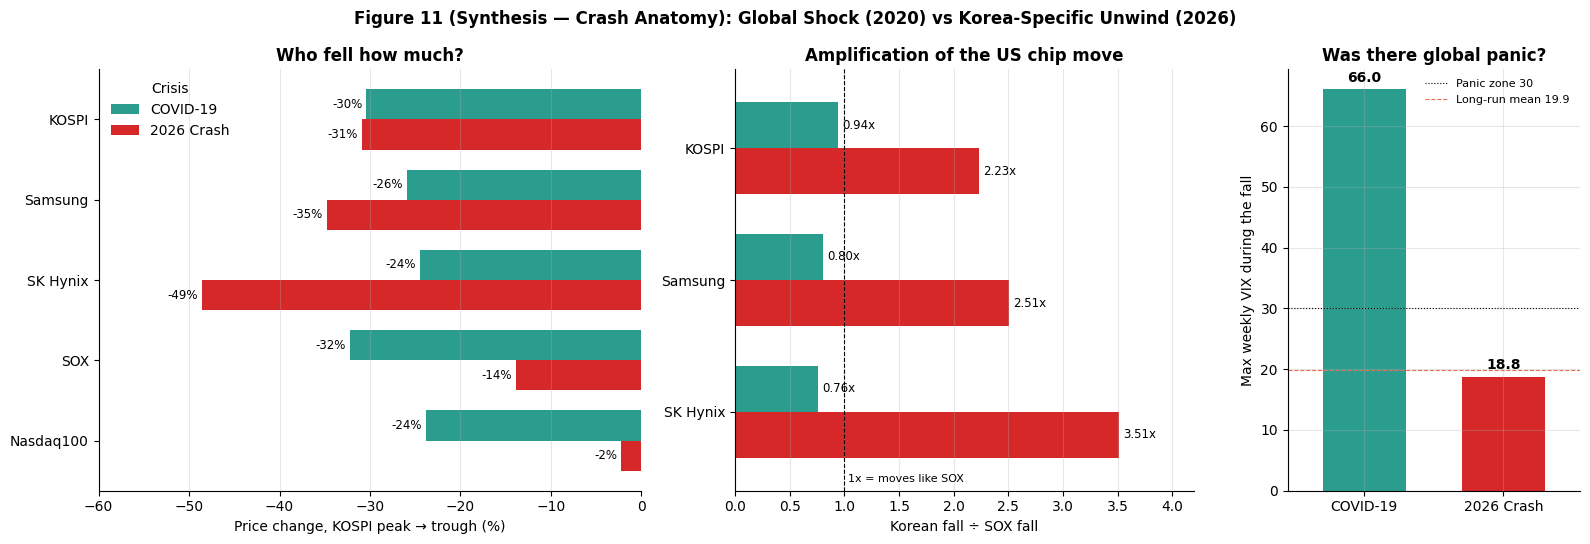

In [24]:
ANAT = pd.Series({"KOSPI": "KOSPI", "Samsung": "Samsung", "SK_Hynix": "SK Hynix",
                  "SOX_Index": "SOX", "Nasdaq100_Index": "Nasdaq100"})
anat = crises.loc[PAIR].apply(
    lambda r: (df_w.loc[r["Trough"], ANAT.index] / df_w.loc[r["Peak"], ANAT.index] - 1) * 100, axis=1
).rename(columns=ANAT).T                                      # rows = assets, columns = crises
amp = anat.loc[["KOSPI", "Samsung", "SK Hynix"]] / anat.loc["SOX"]
PAIR_COLORS = pd.Index(PAIR).map(CRISIS_COLORS).tolist()

fig, ax = plt.subplot_mosaic([["A", "B", "C"]], figsize=(16, 5.5), gridspec_kw={"width_ratios": [1.3, 1.1, 0.7]})
a = ax["A"]
anat.plot(kind="barh", ax=a, color=PAIR_COLORS, width=0.75)
pd.Series(a.containers).apply(lambda cont: a.bar_label(cont, fmt="%.0f%%", padding=3, fontsize=8.5))
a.invert_yaxis(); a.set_xlim(-60, 0); a.grid(axis="y", visible=False)
a.set_xlabel("Price change, KOSPI peak → trough (%)"); a.set_title("Who fell how much?")

b = ax["B"]
amp.plot(kind="barh", ax=b, color=PAIR_COLORS, width=0.7, legend=False)
pd.Series(b.containers).apply(lambda cont: b.bar_label(cont, fmt="%.2fx", padding=3, fontsize=8.5))
b.axvline(1, color="black", ls="--", lw=0.8); b.invert_yaxis(); b.set_xlim(0, 4.2); b.grid(axis="y", visible=False)
b.text(1.03, 0.02, "1x = moves like SOX", transform=b.get_xaxis_transform(), fontsize=8)
b.set_xlabel("Korean fall ÷ SOX fall"); b.set_title("Amplification of the US chip move")

c = ax["C"]
crises.loc[PAIR, "Max_VIX"].plot(kind="bar", ax=c, color=PAIR_COLORS, width=0.6, rot=0)
c.bar_label(c.containers[0], fmt="%.1f", padding=3, fontweight="bold")
c.axhline(30, color="black", ls=":", lw=0.8, label="Panic zone 30")
c.axhline(vix_mean, color=C["vix"], ls="--", lw=0.8, label=f"Long-run mean {vix_mean:.1f}")
c.set_ylabel("Max weekly VIX during the fall"); c.set_xlabel(""); c.legend(handles=c.lines, loc="upper right", fontsize=8)
c.set_title("Was there global panic?")

fig.suptitle("Figure 11 (Synthesis — Crash Anatomy): Global Shock (2020) vs Korea-Specific Unwind (2026)",
             fontweight="bold")
fig.tight_layout()
save(fig, "fig11_synthesis_crash_anatomy")

In [25]:
display(pd.concat({"Price change %": anat, "Amplification (x)": amp}, axis=1).round(2))
A, M = anat, amp
display(Markdown(f"""
**ข้อสรุปสำคัญ:** COVID-19: ทุกตลาดร่วงระดับใกล้เคียงกัน ระหว่าง {A['COVID-19'].max():.1f}% ถึง {A['COVID-19'].min():.1f}% → การร่วงพร้อมกันทั่วโลก (Synchronized Global Shock) 2026: ตลาดสหรัฐฯ แทบไม่กระทบ — Nasdaq100 {A.loc['Nasdaq100','2026 Crash']:.1f}%, SOX {A.loc['SOX','2026 Crash']:.1f}% — ขณะที่ Samsung {A.loc['Samsung','2026 Crash']:.1f}% และ SK Hynix **{A.loc['SK Hynix','2026 Crash']:.1f}%** อัตราขยายปี 2026: Samsung **{M.loc['Samsung','2026 Crash']:.2f}x**, SK Hynix **{M.loc['SK Hynix','2026 Crash']:.2f}x** เทียบกับ COVID-19 ที่อยู่ระหว่าง {M['COVID-19'].min():.2f}x–{M['COVID-19'].max():.2f}x (หุ้นเกาหลีเคยเคลื่อนไหวน้อยกว่าหรือใกล้เคียงต้นทาง) VIX สูงสุดปี 2026 = **{crises.loc['2026 Crash','Max_VIX']:.1f}** เทียบกับ {crises.loc['COVID-19','Max_VIX']:.1f} ในช่วง COVID-19 ตลาดโลกไม่ได้ตื่นตระหนก **สรุป:** ปี 2026 เป็นการปรับฐานที่เริ่มจากหุ้นชิปสหรัฐฯ แล้วถูก**ขยายผลอย่างรุนแรงภายในตลาดเกาหลีเอง** ไม่ใช่วิกฤตระดับโลก
"""))


Price change %            Amplification (x)           
Crisis          COVID-19 2026 Crash          COVID-19 2026 Crash
KOSPI             -30.41     -30.86              0.94       2.23
Samsung           -25.94     -34.75              0.80       2.51
SK Hynix          -24.44     -48.55              0.76       3.51
SOX               -32.25     -13.84               NaN        NaN
Nasdaq100         -23.76      -2.25               NaN        NaN


**ข้อสรุปสำคัญ:** COVID-19: ทุกตลาดร่วงระดับใกล้เคียงกัน ระหว่าง -23.8% ถึง -32.2% → การร่วงพร้อมกันทั่วโลก (Synchronized Global Shock) 2026: ตลาดสหรัฐฯ แทบไม่กระทบ — Nasdaq100 -2.2%, SOX -13.8% — ขณะที่ Samsung -34.7% และ SK Hynix **-48.6%** อัตราขยายปี 2026: Samsung **2.51x**, SK Hynix **3.51x** เทียบกับ COVID-19 ที่อยู่ระหว่าง 0.76x–0.94x (หุ้นเกาหลีเคยเคลื่อนไหวน้อยกว่าหรือใกล้เคียงต้นทาง) VIX สูงสุดปี 2026 = **18.8** เทียบกับ 66.0 ในช่วง COVID-19 ตลาดโลกไม่ได้ตื่นตระหนก **สรุป:** ปี 2026 เป็นการปรับฐานที่เริ่มจากหุ้นชิปสหรัฐฯ แล้วถูก**ขยายผลอย่างรุนแรงภายในตลาดเกาหลีเอง** ไม่ใช่วิกฤตระดับโลก


> **ข้อควรระวัง:** อัตราขยายหารด้วยการร่วงของ SOX ซึ่งมีค่าเพียงราว −14% ตัวหารขนาดเล็กทำให้อัตราส่วนพองตัวได้ง่าย จึงต้องแสดงตัวเลขการร่วงจริง (แผง 1) ควบคู่กับอัตราส่วน (แผง 2) เสมอ
>
> **ที่มา:** yfinance · คำนวณโดยผู้จัดทำ

### กราฟที่ 12 · หลักฐานเชิงพฤติกรรมของภาวะ Forced Unwind (สร้างใหม่)
**คำถามของกราฟ:** มีหลักฐานอะไรบ้างที่บ่งชี้ว่าการร่วงครั้งนี้เกิดจากการปิดสถานะแบบถูกบังคับ ทั้งที่ไม่มีข้อมูลหนี้มาร์จิ้นเป็น time series

**สิ่งที่กราฟแสดง:** Dumbbell chart 5 แถว 1 แถวต่อ 1 หลักฐาน จุดเขียวคือ COVID-19 จุดแดงคือ 2026 ลูกศรชี้ทิศทางจาก COVID-19 ไป 2026 และคอลัมน์ขวาสรุปความหมายของแต่ละแถว
- ความเร็ว: จำนวนสัปดาห์จากจุดพีคถึงจุดต่ำสุด (น้อย = เร็ว)
- อัตราขยายเทียบ SOX: การร่วงของหุ้นเกาหลี ÷ การร่วงของ SOX (เส้นประ 1x = ร่วงเท่า SOX)
- ความผันผวน 4 สัปดาห์สูงสุดของหุ้นชิประหว่างช่วงร่วง
- สัดส่วนความเสียหายจาก Top-5 พร้อมขีดแนวตั้งแสดงน้ำหนักของ Top-5 ณ จุดพีคของแต่ละวิกฤต
- VIX สูงสุดระหว่างช่วงร่วง (เส้นประ 30 = เขตตื่นตระหนก)

**วิธีอ่าน:** แต่ละแถวใช้แกนของตัวเองเริ่มที่ 0 ให้เปรียบเทียบสองจุดภายในแถวเดียวกัน ไม่เทียบข้ามแถว เพราะหน่วยต่างกัน ตัวเลขทุกตัวดึงจากตัวแปรที่คำนวณแล้วในกราฟ 4, 6, 10 และ 11

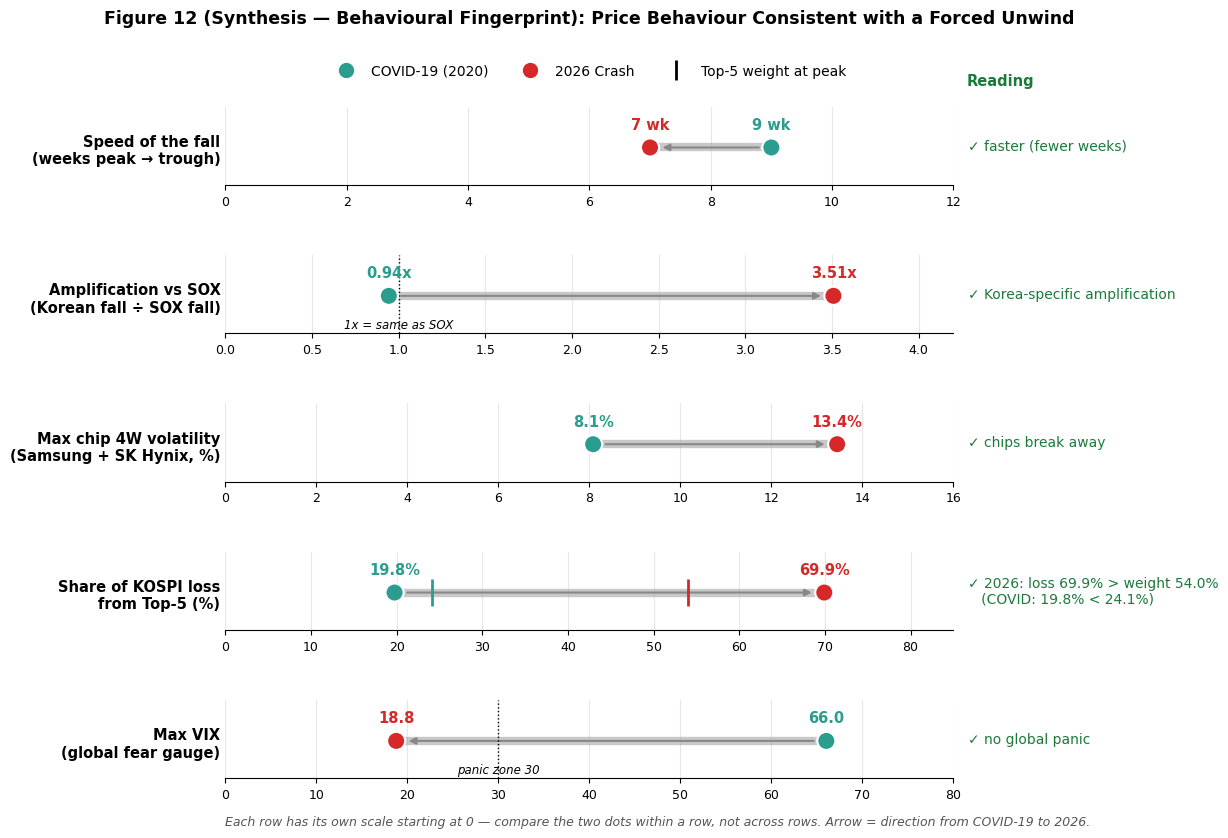

In [26]:
w_top5 = loss.iloc[:, 0]
CV_COL, NW_COL = PAIR_COLORS
evidence = pd.DataFrame({
    "Speed (weeks peak → trough)":     crises.loc[PAIR, "Weeks_to_trough"],
    "Max amplification vs SOX (x)":    amp.max(),
    "Max chip 4W volatility (%)":      vol_max["Tech_Vol_4W"],
    "Share of KOSPI loss from Top-5 (%)": loss.iloc[:, 1],
    "Max VIX":                         crises.loc[PAIR, "Max_VIX"],
}).astype(float)

# One row per metric: label, values, number format, axis max, reference line and reading
rows = pd.DataFrame({
    "label":  ["Speed of the fall\n(weeks peak → trough)", "Amplification vs SOX\n(Korean fall ÷ SOX fall)",
               "Max chip 4W volatility\n(Samsung + SK Hynix, %)", "Share of KOSPI loss\nfrom Top-5 (%)",
               "Max VIX\n(global fear gauge)"],
    "covid":  evidence.loc["COVID-19"].values,
    "new":    evidence.loc["2026 Crash"].values,
    "fmt":    ["{:.0f} wk", "{:.2f}x", "{:.1f}%", "{:.1f}%", "{:.1f}"],
    "xmax":   [12, 4.2, 16, 85, 80],
    "ref":    [np.nan, 1.0, np.nan, np.nan, 30.0],
    "ref_label": ["", "1x = same as SOX", "", "", "panic zone 30"],
    "reading": ["✓ faster (fewer weeks)", "✓ Korea-specific amplification", "✓ chips break away",
                f"✓ 2026: loss {loss.iloc[1,1]:.1f}% > weight {w_top5.iloc[1]:.1f}%\n   (COVID: {loss.iloc[0,1]:.1f}% < {w_top5.iloc[0]:.1f}%)",
                "✓ no global panic"],
})

fig, axes = plt.subplots(len(rows), 1, figsize=(13, 8.5))
fig.subplots_adjust(hspace=0.9, left=0.22, right=0.78, top=0.86, bottom=0.07)

def dumbbell_row(r):
    ax, y = axes[r.name], 0
    ax.plot([r.covid, r.new], [y, y], color="#c8c8c8", lw=6, solid_capstyle="round", zorder=1)
    ax.annotate("", xy=(r.new, y), xytext=(r.covid, y),
                arrowprops=dict(arrowstyle="-|>", color="#888888", lw=1.5, shrinkA=9, shrinkB=9), zorder=2)
    ax.scatter([r.covid, r.new], [y, y], s=170, color=[CV_COL, NW_COL], zorder=3, edgecolor="white", lw=1.5)
    ax.text(r.covid, y + 0.55, r.fmt.format(r.covid), ha="center", color=CV_COL, fontweight="bold", fontsize=10.5)
    ax.text(r.new, y + 0.55, r.fmt.format(r.new), ha="center", color=NW_COL, fontweight="bold", fontsize=10.5)
    if pd.notna(r.ref):
        ax.axvline(r.ref, color="black", ls=":", lw=1)
        ax.text(r.ref, -0.95, r.ref_label, ha="center", fontsize=8.5, style="italic")
    ax.set_xlim(0, r.xmax); ax.set_ylim(-1.1, 1.2)
    ax.set_yticks([0]); ax.set_yticklabels([r.label], fontsize=10.5, fontweight="bold")
    ax.tick_params(axis="y", length=0); ax.tick_params(axis="x", labelsize=9)
    ax.spines["left"].set_visible(False); ax.grid(axis="y", visible=False)
    ax.text(1.02, 0.5, r.reading, transform=ax.transAxes, va="center", fontsize=10, color="#1b7a3a")

rows.apply(dumbbell_row, axis=1)
# Top-5 weight at each peak, drawn on the loss-share row
axes[3].scatter(w_top5.values, [0, 0], marker="|", s=380, color=[CV_COL, NW_COL], lw=2, zorder=4)

handles = [plt.Line2D([], [], marker="o", ls="", color=CV_COL, ms=10, label="COVID-19 (2020)"),
           plt.Line2D([], [], marker="o", ls="", color=NW_COL, ms=10, label="2026 Crash"),
           plt.Line2D([], [], marker="|", ls="", color="black", ms=14, mew=2, label="Top-5 weight at peak")]
fig.legend(handles=handles, loc="upper center", ncol=3, bbox_to_anchor=(0.5, 0.925), fontsize=10)
fig.text(0.79, 0.885, "Reading", fontweight="bold", color="#1b7a3a", fontsize=10.5)
fig.text(0.22, 0.015, "Each row has its own scale starting at 0 — compare the two dots within a row, not across rows. "
         "Arrow = direction from COVID-19 to 2026.", fontsize=9, style="italic", color="#555555")
fig.suptitle("Figure 12 (Synthesis — Behavioural Fingerprint): Price Behaviour Consistent with a Forced Unwind",
             fontweight="bold", fontsize=12.5, y=0.975)
save(fig, "fig12_synthesis_forced_unwind")

In [27]:
display(evidence.round(2).T)
E = evidence
display(Markdown(f"""
**ข้อสรุปสำคัญ:** กราฟนี้สร้างขึ้นเพื่อรับมือข้อจำกัดด้านข้อมูลโดยตรง: ไม่สามารถเข้าถึงข้อมูลหนี้มาร์จิ้นหรืออัตราส่วนหนี้รายวันเป็น time series ผ่าน Public API จึงนำเสนอ**ร่องรอยเชิงประจักษ์ (Empirical Fingerprint)** แทนการฟันธง หลักฐานทั้ง 5 แถวชี้ไปทางเดียวกัน — ร่วงเร็วกว่า ({E.iloc[1,0]:.0f} สัปดาห์ เทียบกับ {E.iloc[0,0]:.0f} สัปดาห์ ที่ความลึกใกล้เคียงกัน), หุ้นกลุ่มเดียวเหวี่ยงแรงกว่าต้นทาง (อัตราขยาย {E.iloc[1,1]:.2f}x เทียบกับ {E.iloc[0,1]:.2f}x), ความผันผวนหุ้นชิปพุ่งขึ้น ({E.iloc[1,2]:.1f}% เทียบกับ {E.iloc[0,2]:.1f}%), ความเสียหายกระจุกเกินน้ำหนัก ({E.iloc[1,3]:.1f}% เทียบกับน้ำหนัก {w_top5.iloc[1]:.1f}% ขณะที่ COVID-19 ความเสียหาย {E.iloc[0,3]:.1f}% ต่ำกว่าน้ำหนัก {w_top5.iloc[0]:.1f}%) และทั้งหมดเกิดขึ้นโดยที่ตลาดโลกไม่ตื่นตระหนก (VIX {E.iloc[1,4]:.1f} เทียบกับ {E.iloc[0,4]:.1f}) รูปแบบนี้ไม่สอดคล้องกับการปรับมุมมองต่อปัจจัยพื้นฐาน ซึ่งโดยทั่วไปเกิดช้ากว่าและกระจายตัวมากกว่า
"""))


Crisis,COVID-19,2026 Crash
Speed (weeks peak → trough),9.00,7.00
Max amplification vs SOX (x),0.94,3.51
Max chip 4W volatility (%),8.08,13.45
Share of KOSPI loss from Top-5 (%),19.75,69.93
Max VIX,66.04,18.77



**ข้อสรุปสำคัญ:** กราฟนี้สร้างขึ้นเพื่อรับมือข้อจำกัดด้านข้อมูลโดยตรง: ไม่สามารถเข้าถึงข้อมูลหนี้มาร์จิ้นหรืออัตราส่วนหนี้รายวันเป็น time series ผ่าน Public API จึงนำเสนอ**ร่องรอยเชิงประจักษ์ (Empirical Fingerprint)** แทนการฟันธง หลักฐานทั้ง 5 แถวชี้ไปทางเดียวกัน — ร่วงเร็วกว่า (7 สัปดาห์ เทียบกับ 9 สัปดาห์ ที่ความลึกใกล้เคียงกัน), หุ้นกลุ่มเดียวเหวี่ยงแรงกว่าต้นทาง (อัตราขยาย 3.51x เทียบกับ 0.94x), ความผันผวนหุ้นชิปพุ่งขึ้น (13.4% เทียบกับ 8.1%), ความเสียหายกระจุกเกินน้ำหนัก (69.9% เทียบกับน้ำหนัก 54.0% ขณะที่ COVID-19 ความเสียหาย 19.8% ต่ำกว่าน้ำหนัก 24.1%) และทั้งหมดเกิดขึ้นโดยที่ตลาดโลกไม่ตื่นตระหนก (VIX 18.8 เทียบกับ 66.0) รูปแบบนี้ไม่สอดคล้องกับการปรับมุมมองต่อปัจจัยพื้นฐาน ซึ่งโดยทั่วไปเกิดช้ากว่าและกระจายตัวมากกว่า


> **คำที่ต้องใช้ในการนำเสนอ:** "ลักษณะพฤติกรรมราคา**สอดคล้องกับ**ภาวะ Forced Unwind" (*consistent with a liquidation cascade*) — **ห้าม**เขียนว่า "เกิดจาก Leverage" หรือ "เกิดจาก Margin Call" เพราะไม่มีชุดข้อมูลรองรับที่ประมวลผลเองได้
>
> **ที่มา:** คำนวณโดยผู้จัดทำจากตัวแปรในกราฟ 4, 6, 10 และ 11

#### หลักฐานภายนอกที่สอดคล้องกับกลไก (จากรายงานข่าวการเงิน ไม่ใช่ข้อมูลที่ประมวลผลในโน้ตบุ๊กนี้)

| ประเด็น | รายละเอียดตามรายงาน | แหล่ง |
|---|---|---|
| ผลิตภัณฑ์ใหม่ก่อนจุดพีค | เกาหลีใต้เปิดตัว Single-Stock Leveraged/Inverse ETF บน Samsung และ SK Hynix เป็นครั้งแรก 16 กองทุน เมื่อ 27 พ.ค. 2026 · เกณฑ์หุ้นอ้างอิงคือ มูลค่าตลาด ≥ 10% ของดัชนี และปริมาณซื้อขาย ≥ 5% ซึ่งเข้าเกณฑ์เพียง 2 บริษัทนี้ | The Korea Herald (21 เม.ย. 2026), ETF.com (7 ก.ค. 2026) |
| กลไกขยายแรงขาย | Leveraged ETF ต้อง rebalance ทุกวันปิดตลาดเพื่อรักษาสัดส่วน 2 เท่า เมื่อราคาลงจึงต้องขายหุ้นเพิ่ม | Bloomberg (ผ่าน Investing.com, 24 พ.ค. 2026) |
| วันที่ร่วงหนักที่สุด | 23 มิ.ย. 2026 Samsung −12.31%, SK Hynix −12.47% (หนักที่สุดตั้งแต่ปี 2008) และ KOSPI −9.99% | Financial News (24 มิ.ย. 2026) |
| ขนาดแรงขายเชิงกลไก | Bloomberg Intelligence ประเมินว่ากองทุนกลุ่มนี้ขายหุ้นราว 6 พันล้านดอลลาร์ในวันเดียว คิดเป็นราว 14% ของปริมาณซื้อขายหุ้นทั้งสองตัว | รายงานที่อ้าง Bloomberg Intelligence |
| การกระจุกของการซื้อขาย | Leveraged ETF รวมกับหุ้นแม่ทั้งสองตัวมีสัดส่วนเกิน 70% ของมูลค่าการซื้อขายทั้งตลาด | Bloomberg (8 ก.ค. 2026) |

**ความสอดคล้องกับข้อมูลในโน้ตบุ๊ก:** จุดพีคที่คำนวณได้ (19 มิ.ย. 2026) เกิดขึ้น 3 สัปดาห์หลังการเปิดตัวผลิตภัณฑ์ และสัปดาห์ที่ร่วงแรงที่สุดตรงกับช่วง 23 มิ.ย. ตามรายงาน ซึ่งช่วยอธิบายอัตราขยาย (กราฟ 11) และความผันผวนที่ฉีกตัว (กราฟ 10) ได้ในเชิงกลไก

> **ข้อควรระวัง:** ตัวเลขในตารางนี้มาจากรายงานข่าว ไม่ใช่ raw data ที่ตรวจสอบเองได้ จึงใช้เป็น**หลักฐานสนับสนุนเชิงบริบท** ไม่ใช่ตัวแปรในการคำนวณ ต้องเขียนว่า "ตามรายงานของ..." ทุกครั้ง · ไม่ใช้ตัวเลขจำนวนบัญชีที่ถูก Margin Call เพราะแต่ละแหล่งรายงานต่างกันเกือบ 10 เท่า · ยอดสินเชื่อมาร์จิ้นจาก KOFIA ควรตรวจสอบกับ freesis.kofia.or.kr โดยตรงก่อนใช้อ้างอิงในเล่ม

## 8. สรุปผลตามสมมติฐาน
ตารางถัดไปสร้างจากตัวแปรที่คำนวณในโน้ตบุ๊ก จึงอัปเดตอัตโนมัติเมื่อรันข้อมูลใหม่

In [28]:
H = pd.DataFrame([
    ["H1 · เศรษฐกิจชะลอพร้อมเงินเฟ้อสูง",
     f"กราฟ 2: สัญญาณ Stagflation ใน 12 เดือนก่อนพีค = {stag_pre_peak.max()} เดือนทุกวิกฤต · CLI {th(cli_tail.index[-1])} = {cli_tail.iloc[-1]:.2f} · "
     f"กราฟ 3: Brent +{(brent_mar/brent_feb-1)*100:.0f}% ใน 1 เดือน, CPI ทะลุ 3% ภายในไม่กี่เดือน (r ≈ {krw_17.min():.2f}–{krw_17.max():.2f} ที่ lag 1–7 เดือน), ดอกเบี้ยไม่เปลี่ยน",
     "สนับสนุนบางส่วน: มีแรงกดดันจากต้นทุน แต่ไม่มีภาวะ Stagflation"],
    ["H2 · ความตื่นตระหนกระดับโลก / ค่าเงิน",
     f"กราฟ 4: VIX สูงสุด {vx['2026 Crash']:.1f} (< ค่าเฉลี่ย {vix_mean:.1f}) · ทองคำชะลอจาก {dm.loc[g_pk,'Gold_YoY']:+.1f}% เหลือ {dm.loc['2026-06-01','Gold_YoY']:+.1f}% · "
     f"กราฟ 5: หลังค่าเงินทะลุกรอบ KOSPI เดือนถัดไป median {z['median']:+.2f}%, mean {z['mean']:+.2f}% (n = {z['n']:.0f})",
     "ไม่สนับสนุน: ทั้งความตื่นตระหนกและค่าเงินไม่ใช่ตัวจุดชนวน"],
    ["H3 · ความเปราะบางจากการกระจุกตัว",
     f"กราฟ 9: CR5 ทรงตัว {five_era.min():.1f}–{five_era.max():.1f}% (2022–25) → {cy[2026]:.1f}% ในปี 2026 สูงสุด {cr5.max():.1f}% · "
     f"กราฟ 10: Top-5 สร้างความเสียหาย {L.iloc[1,1]:.1f}% เทียบน้ำหนัก {L.iloc[1,0]:.1f}%",
     "สนับสนุน: หลักฐานแข็งแรงที่สุด"],
    ["H4 · การส่งผ่านจากหุ้นเทคสหรัฐฯ",
     f"กราฟ 7: r กับ SOX = {kc['SOX']:.2f}, Nasdaq100 = {kc['Nasdaq100']:.2f} · "
     f"กราฟ 11: SOX {A.loc['SOX','2026 Crash']:.1f}% แต่ SK Hynix {A.loc['SK Hynix','2026 Crash']:.1f}% (ขยาย {M.loc['SK Hynix','2026 Crash']:.2f}x)",
     "สนับสนุนฝั่งการส่งผ่าน · ฝั่งการปรับลดมูลค่า (Valuation) ยังสรุปไม่ได้ เพราะไม่มีข้อมูลกำไรต่อหุ้น"],
], columns=["สมมติฐาน", "หลักฐานจากข้อมูล", "ผล"])
display(H.style.hide(axis="index").set_properties(**{"text-align": "left", "white-space": "normal"}))

display(Markdown(f"""
### ข้อสรุปรวม
ข้อมูลชี้ว่าการร่วงของ KOSPI ปี 2026 มีลักษณะใกล้เคียงกับ**การปรับฐานของกลุ่มเซมิคอนดักเตอร์ที่ถูกขยายผลโดยโครงสร้างตลาดที่กระจุกตัว** มากกว่าวิกฤตเศรษฐกิจมหภาคหรือความตื่นตระหนกระดับโลก โดยมีหลักฐาน 4 ชั้น

1. **เศรษฐกิจจริงไม่ได้พัง** — ว่างงาน {u_jun:.2f}% และ CLI ยังอยู่เหนือ 100 ({cli_tail.iloc[-1]:.2f})
2. **ตลาดโลกไม่ตื่นตระหนก** — VIX สูงสุดเพียง {vx['2026 Crash']:.1f}
3. **ความเสียหายกระจุกผิดสัดส่วน** — หุ้น 5 ตัวที่มีน้ำหนัก {L.iloc[1,0]:.1f}% สร้างความเสียหาย {L.iloc[1,1]:.1f}%
4. **ความเร็วผิดปกติ** — ร่วง {-crises.loc['2026 Crash','Drawdown_%']:.1f}% ภายใน {crises.loc['2026 Crash','Weeks_to_trough']:.0f} สัปดาห์ เร็วที่สุดใน 4 วิกฤต

*ข้อมูล ณ {thd(DATA_ASOF)}*
"""))

สมมติฐาน,หลักฐานจากข้อมูล,ผล
H1 · เศรษฐกิจชะลอพร้อมเงินเฟ้อสูง,"กราฟ 2: สัญญาณ Stagflation ใน 12 เดือนก่อนพีค = 0 เดือนทุกวิกฤต · CLI พ.ค. 2026 = 100.44 · กราฟ 3: Brent +54% ใน 1 เดือน, CPI ทะลุ 3% ภายในไม่กี่เดือน (r ≈ 0.50–0.52 ที่ lag 1–7 เดือน), ดอกเบี้ยไม่เปลี่ยน",สนับสนุนบางส่วน: มีแรงกดดันจากต้นทุน แต่ไม่มีภาวะ Stagflation
H2 · ความตื่นตระหนกระดับโลก / ค่าเงิน,"กราฟ 4: VIX สูงสุด 18.8 (< ค่าเฉลี่ย 19.9) · ทองคำชะลอจาก +84.2% เหลือ +24.6% · กราฟ 5: หลังค่าเงินทะลุกรอบ KOSPI เดือนถัดไป median +3.31%, mean +0.38% (n = 25)",ไม่สนับสนุน: ทั้งความตื่นตระหนกและค่าเงินไม่ใช่ตัวจุดชนวน
H3 · ความเปราะบางจากการกระจุกตัว,กราฟ 9: CR5 ทรงตัว 28.9–31.8% (2022–25) → 45.8% ในปี 2026 สูงสุด 55.5% · กราฟ 10: Top-5 สร้างความเสียหาย 69.9% เทียบน้ำหนัก 54.0%,สนับสนุน: หลักฐานแข็งแรงที่สุด
H4 · การส่งผ่านจากหุ้นเทคสหรัฐฯ,"กราฟ 7: r กับ SOX = 0.59, Nasdaq100 = 0.51 · กราฟ 11: SOX -13.8% แต่ SK Hynix -48.6% (ขยาย 3.51x)",สนับสนุนฝั่งการส่งผ่าน · ฝั่งการปรับลดมูลค่า (Valuation) ยังสรุปไม่ได้ เพราะไม่มีข้อมูลกำไรต่อหุ้น



### ข้อสรุปรวม
ข้อมูลชี้ว่าการร่วงของ KOSPI ปี 2026 มีลักษณะใกล้เคียงกับ**การปรับฐานของกลุ่มเซมิคอนดักเตอร์ที่ถูกขยายผลโดยโครงสร้างตลาดที่กระจุกตัว** มากกว่าวิกฤตเศรษฐกิจมหภาคหรือความตื่นตระหนกระดับโลก โดยมีหลักฐาน 4 ชั้น

1. **เศรษฐกิจจริงไม่ได้พัง** — ว่างงาน 2.75% และ CLI ยังอยู่เหนือ 100 (100.44)
2. **ตลาดโลกไม่ตื่นตระหนก** — VIX สูงสุดเพียง 18.8
3. **ความเสียหายกระจุกผิดสัดส่วน** — หุ้น 5 ตัวที่มีน้ำหนัก 54.0% สร้างความเสียหาย 69.9%
4. **ความเร็วผิดปกติ** — ร่วง 30.9% ภายใน 7 สัปดาห์ เร็วที่สุดใน 4 วิกฤต

*ข้อมูล ณ 18 ก.ย. 2026*


## 9. ข้อจำกัดของข้อมูลและงานในอนาคต (Data Limitation & Future Work)

### 9.1 ข้อจำกัดของข้อมูล
- **Leverage / Margin Debt:** ข้อมูลสินเชื่อมาร์จิ้นรายวันของนักลงทุนรายย่อยและสถาบัน (Margin Loan Balance จาก KRX/KOFIA) ไม่สามารถเข้าถึงเป็น time series ผ่าน Public API จึงใช้ร่องรอยเชิงพฤติกรรม (กราฟ 12) เป็นตัวแทน
- **อัตราดอกเบี้ย:** `INTDSRKRM193N` เป็น Discount Rate ไม่ใช่ BOK Base Rate ระดับต่ำกว่าความจริงราว 1.5 จุด ใช้ได้เฉพาะทิศทาง จึงไม่คำนวณ Real Rate
- **CR5:** ใช้จำนวนหุ้นจดทะเบียน ณ วันดึงข้อมูลย้อนหลังทั้งช่วง ตัวหารที่ปรับแล้วยังเป็นค่าประมาณ และจำนวนบริษัทในสูตรเปลี่ยน 3 → 4 → 5 การเปรียบเทียบจึงจำกัดอยู่ในยุค 5 บริษัท (2022 เป็นต้นไป)
- **GDP:** interpolate จากรายไตรมาสโดยใช้ค่าไตรมาสถัดไป ห้ามใช้พยากรณ์ และไม่มีข้อมูลตั้งแต่ พ.ค. 2026
- **CLI:** มีข้อมูลถึง พ.ค. 2026 (ก่อนจุดพีค 1 เดือน)
- **VIX:** เป็นฐานรายสัปดาห์ อาจต่ำกว่าจุดสูงสุดระหว่างวัน
- **ความเป็นเหตุเป็นผล:** ความสัมพันธ์ที่พบทั้งหมดเป็นเชิงสถิติ ไม่ได้พิสูจน์ความเป็นเหตุเป็นผล

### 9.2 งานในอนาคต
- **ยืนยัน Forced Unwind โดยตรง:** หากเข้าถึงข้อมูล Margin Balance รายวัน (KOFIA) และ AUM / flow รายวันของ Single-Stock Leveraged ETF ได้ จะสร้างแบบจำลองถดถอยเพื่อหาจุดแตกหักของระดับหนี้ และวัดสัดส่วนแรงขายจากการ rebalance ได้โดยตรง
- **อัตราดอกเบี้ยที่ถูกต้อง:** เปลี่ยนเป็น Base Rate จากระบบ ECOS ของธนาคารกลางเกาหลี เพื่อนำการวิเคราะห์ Real Rate / Rate Trap กลับเข้ามา
- **H4 ฝั่ง Valuation:** เพิ่มข้อมูลกำไรต่อหุ้น (EPS / Forward P/E) เพื่อแยกว่าการร่วงมาจากการลดมูลค่าหรือการลดประมาณการกำไร
- **Early Warning System (ย้ายมาจาก Fig 17 เดิม):** ผลทดสอบเบื้องต้นพบว่าการใช้เกณฑ์ค่าเงินรายเดือนเพียงอย่างเดียวให้สัญญาณช้าและมีประโยชน์จำกัด (ดูกราฟ 5) แนวทางต่อไปคือใช้ข้อมูลรายวัน และเพิ่มเงื่อนไขระดับการกระจุกตัว (CR5) ระยะห่างของดัชนีจากเส้นค่าเฉลี่ย และขนาด AUM ของ Leveraged ETF ต่อมูลค่าตลาดหุ้นแม่ แล้วทำ backtest อย่างเป็นระบบ
- **ตัวชี้วัดการกระจุกตัวเพิ่มเติม:** คำนวณ Herfindahl-Hirschman Index (HHI) ควบคู่กับ CR5 เพื่อยืนยันผลด้วยตัวชี้วัดมาตรฐานอีกตัว

---
### ภาคผนวก · การเปลี่ยนแปลงจากโน้ตบุ๊กฉบับเดิม
| กราฟใหม่ | เดิม | การเปลี่ยนแปลง |
|---|---|---|
| 1 | Fig 1 | ระบุเดือนสุดท้ายของ GDP บนกราฟ |
| 2 | Fig 2 | ใช้ `fill_between` แทน loop · เขียนคำอธิบายใหม่ (Stagflation เป็นสัญญาณตามหลัง) |
| 3 | Fig 3 + Fig 6 | ยุบรวม ซูม 2024–2026 ตัด Real Rate · แยกน้ำมันกับ CPI เป็นคนละแผงแทนกราฟสองแกน Y · แผง lag correlation เต็มความกว้าง |
| 4 | Fig 4 | เพิ่มจุด VIX สูงสุดของแต่ละวิกฤต · แก้คำอธิบายทองคำ |
| 5 | Fig 5 | ลดเหลือแผงเดียว นำเสนอเป็น Null Result |
| 6 | Fig 7 | ใช้ `bar_label` แทน loop |
| 7 | Fig 9 | Heatmap → Bar Chart (ตัวแปรครบ 9 ตัว) |
| 8 | Fig 10 | ป้ายกำกับสร้างด้วย vectorised string |
| 9 | Fig 11 | ตัด CR5 Raw · แบ่งยุคตามจำนวนบริษัท |
| 10 | Fig 12 | แยกแผงซ้ายเป็น 2 แผง · Volatility เต็มความกว้าง · วัดความผันผวนช่วงพีค → จุดต่ำสุด |
| 11 | Fig 16 | ใช้ `.plot(kind="barh")` + `bar_label` |
| 12 | ใหม่ | Forced Unwind Evidence แบบ Dumbbell chart + หลักฐานภายนอก |
| — | Fig 8, 13, 14, 15, 17 | ตัดออก (Fig 17 → Future Work) |